In [1]:
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [2]:
data = pd.read_csv("data_science_competition_2024.csv")

In [3]:
# Set pandas display option to show all columns
pd.set_option('display.max_columns', None)
data.head()

,Unnamed: 0,loan_id,gender,disbursemet_date,currency,country,sex,is_employed,job,location,loan_amount,number_of_defaults,outstanding_balance,interest_rate,age,number_of_defaults.1,remaining term,salary,marital_status,age.1,Loan Status
0,0,8d05de78-ff32-46b1-aeb5-b3190f9c158a,female,2022 10 29,USD,Zimbabwe,female,True,Teacher,Beitbridge,39000.0,0,48653.011473,0.22,37,0,47,3230.038869,married,37,Did not default
1,1,368bf756-fcf2-4822-9612-f445d90b485b,other,2020 06 06,USD,Zimbabwe,other,True,Teacher,Harare,27000.0,2,28752.062237,0.20,43,2,62,3194.139103,single,43,Did not default
2,2,6e3be39e-49b5-45b5-aab6-c6556de53c6f,other,2023 09 29,USD,Zimbabwe,other,True,Nurse,Gweru,35000.0,1,44797.554126,0.22,43,1,57,3330.826656,married,43,Did not default
3,3,191c62f8-2211-49fe-ba91-43556b307871,female,2022 06 22,USD,Zimbabwe,female,True,Doctor,Rusape,24000.0,0,35681.496413,0.23,47,0,42,2246.797020,divorced,47,Did not default
4,4,477cd8a1-3b01-4623-9318-8cd6122a8346,male,2023 02 08,USD,Zimbabwe,male,True,Nurse,Chipinge,19000.0,0,34156.055882,0.20,42,0,45,2310.858441,married,42,Did not default


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 21 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Unnamed: 0            100000 non-null  int64  
 1   loan_id               100000 non-null  object 
 2   gender                100000 non-null  object 
 3   disbursemet_date      100000 non-null  object 
 4   currency              100000 non-null  object 
 5   country               99900 non-null   object 
 6   sex                   100000 non-null  object 
 7   is_employed           100000 non-null  bool   
 8   job                   95864 non-null   object 
 9   location              99405 non-null   object 
 10  loan_amount           100000 non-null  float64
 11  number_of_defaults    100000 non-null  int64  
 12  outstanding_balance   100000 non-null  float64
 13  interest_rate         100000 non-null  float64
 14  age                   100000 non-null  int64  
 15  n

In [5]:
# dropping unnecessary columns: 'Unnamed: 0' and 'loan_id'
data = data.drop(['Unnamed: 0', 'loan_id'], axis=1)

In [6]:
# Checking if the data in 'gender' and 'sex' columns are the same
comparison = data['gender'] == data['sex']

# Display the comparison result
comparison.value_counts()

True    100000
dtype: int64

In [7]:
# Checking if the data in 'age' and 'age.1' columns are the same
comparison = data['age'] == data['age.1']

# Display the comparison result
comparison.value_counts()

True    100000
dtype: int64

In [8]:
# since the gender, sex and number of defaults.1 are the same, the duplicate columns are dropped
# Drop the columns 'sex', 'age.1', 'number_of_defaults.1'
data = data.drop(['sex', 'age.1', 'number_of_defaults.1'], axis=1)
data.head()

,gender,disbursemet_date,currency,country,is_employed,job,location,loan_amount,number_of_defaults,outstanding_balance,interest_rate,age,remaining term,salary,marital_status,Loan Status
0,female,2022 10 29,USD,Zimbabwe,True,Teacher,Beitbridge,39000.0,0,48653.011473,0.22,37,47,3230.038869,married,Did not default
1,other,2020 06 06,USD,Zimbabwe,True,Teacher,Harare,27000.0,2,28752.062237,0.20,43,62,3194.139103,single,Did not default
2,other,2023 09 29,USD,Zimbabwe,True,Nurse,Gweru,35000.0,1,44797.554126,0.22,43,57,3330.826656,married,Did not default
3,female,2022 06 22,USD,Zimbabwe,True,Doctor,Rusape,24000.0,0,35681.496413,0.23,47,42,2246.797020,divorced,Did not default
4,male,2023 02 08,USD,Zimbabwe,True,Nurse,Chipinge,19000.0,0,34156.055882,0.20,42,45,2310.858441,married,Did not default


In [9]:
# checking for missing values 
data.isnull().sum()

gender                    0
disbursemet_date          0
currency                  0
country                 100
is_employed               0
job                    4136
location                595
loan_amount               0
number_of_defaults        0
outstanding_balance       0
interest_rate             0
age                       0
remaining term            0
salary                    0
marital_status            0
Loan Status               0
dtype: int64

In [10]:
# checking the values in country column 
data["country"].value_counts()

Zimbabwe    99787
zimbabwe      100
Zim            13
Name: country, dtype: int64

In [11]:
# Standardize the 'country' column
data['country'] = data['country'].replace(['zimbabwe', 'Zim'], 'Zimbabwe')

# Fill any missing values in 'country' with 'Zimbabwe'
data['country'] = data['country'].fillna('Zimbabwe')

# Check the values in the 'country' column to verify the changes
data['country'].value_counts()

Zimbabwe    100000
Name: country, dtype: int64

In [12]:
# checking for classes in currency column
data["currency"].value_counts()

USD     99980
$USD       20
Name: currency, dtype: int64

In [13]:
# Replace currency values to USD
data['currency'] = data['currency'].replace(['$USD'], 'USD')

In [14]:
# checking for classes in the is_employed variable
data["is_employed"].value_counts()

True     95864
False     4136
Name: is_employed, dtype: int64

In [15]:
# checking for classes in the marital_staus
data["marital_status"].value_counts()

married     44710
divorced    26465
single      25698
             3127
Name: marital_status, dtype: int64

In [16]:
# Replace empty strings with 'unknown' in 'marital_status'
data['marital_status'] = data['marital_status'].replace({' ': 'unknown'})
data["marital_status"].value_counts()

married     44710
divorced    26465
single      25698
unknown      3127
Name: marital_status, dtype: int64

the empty string in the marital status column was replaced with unknown to maintain the size of the data and ensure consistency and easy processing 

In [17]:
# Set pandas display option to show all rows
pd.set_option('display.max_rows', None)

# Display all unique values and their counts in 'location' column
location_counts = data['location'].value_counts()
location_counts

Harare                8338
Bulawayo              8078
Mutare                8062
Gweru                 7803
Masvingo              7476
Marondera             7343
Rusape                6378
Chivhu                6257
Plumtree              5431
Beitbridge            5181
Chipinge              4358
Chimanimani           4296
Kwekwe                3401
Chiredzi              3123
Kadoma                3049
Nyanga                2099
Karoi                 1850
Shurugwi              1322
Zvishavane            1276
Gokwe                  901
Kariba                 652
Victoria Falls         211
Redcliff               187
 Masvingo               48
   Harare               44
Hwange                  41
Harare                  40
   Mutare               39
 Mutare                 37
Harare                  36
 Bulawayo               34
   Gweru                34
   Bulawayo             33
 Gweru                  33
   Mutare               33
   Harare               33
Bulawayo                33
 

In [18]:
# Strip leading and trailing spaces from 'location' column
data['location'] = data['location'].str.strip()

# Convert all values to title case for consistent capitalization
data['location'] = data['location'].str.title()

# Display cleaned up value counts
print(data['location'].value_counts())

Harare            8553
Bulawayo          8263
Mutare            8262
Gweru             7983
Masvingo          7665
Marondera         7513
Rusape            6506
Chivhu            6411
Plumtree          5552
Beitbridge        5311
Chipinge          4447
Chimanimani       4388
Kwekwe            3491
Chiredzi          3199
Kadoma            3118
Nyanga            2142
Karoi             1899
Shurugwi          1359
Zvishavane        1301
Gokwe              920
Kariba             671
Victoria Falls     219
Redcliff           191
Hwange              41
Name: location, dtype: int64


In [19]:
# checking for job values
data["job"].value_counts()

Engineer              16524
Nurse                 15284
Data Analyst          13204
Doctor                12186
Software Developer    11932
Teacher                8950
Accountant             7802
SoftwareDeveloper      3564
Data Scientist         3521
Lawyer                 2862
Data Scintist            35
Name: job, dtype: int64

In [21]:
# Replace SoftwareDeveloper to Software Developer
data['job'] = data['job'].replace(['SoftwareDeveloper'], 'Software Developer')
data['job'] = data['job'].replace(['Data Scintist'], 'Data Scientist')

# replace nan with unemployed 
data['job'].fillna('unemployed', inplace=True)

In [22]:
data["job"].value_counts()

Engineer              16524
Software Developer    15496
Nurse                 15284
Data Analyst          13204
Doctor                12186
Teacher                8950
Accountant             7802
unemployed             4136
Data Scientist         3556
Lawyer                 2862
Name: job, dtype: int64

In [23]:
# checking for gender 
data["gender"].value_counts()

male      35028
female    32685
other     32287
Name: gender, dtype: int64

In [24]:
# checking for null values
data.isnull().sum()

gender                   0
disbursemet_date         0
currency                 0
country                  0
is_employed              0
job                      0
location               595
loan_amount              0
number_of_defaults       0
outstanding_balance      0
interest_rate            0
age                      0
remaining term           0
salary                   0
marital_status           0
Loan Status              0
dtype: int64

In [25]:
# replace nan in location with not specified 
data['location'].fillna('not specified', inplace=True)
data.isnull().sum()

gender                 0
disbursemet_date       0
currency               0
country                0
is_employed            0
job                    0
location               0
loan_amount            0
number_of_defaults     0
outstanding_balance    0
interest_rate          0
age                    0
remaining term         0
salary                 0
marital_status         0
Loan Status            0
dtype: int64

Location is a significant factor and I believe missing location data could be meaningful (indicating lack of data rather than a specific location), repacing the nan with 'not specified' is preferable. This approach avoids bias towards any particular location

In [26]:
# checking for duplicates 
data.duplicated().sum()

0

no duplicates found in the dataset

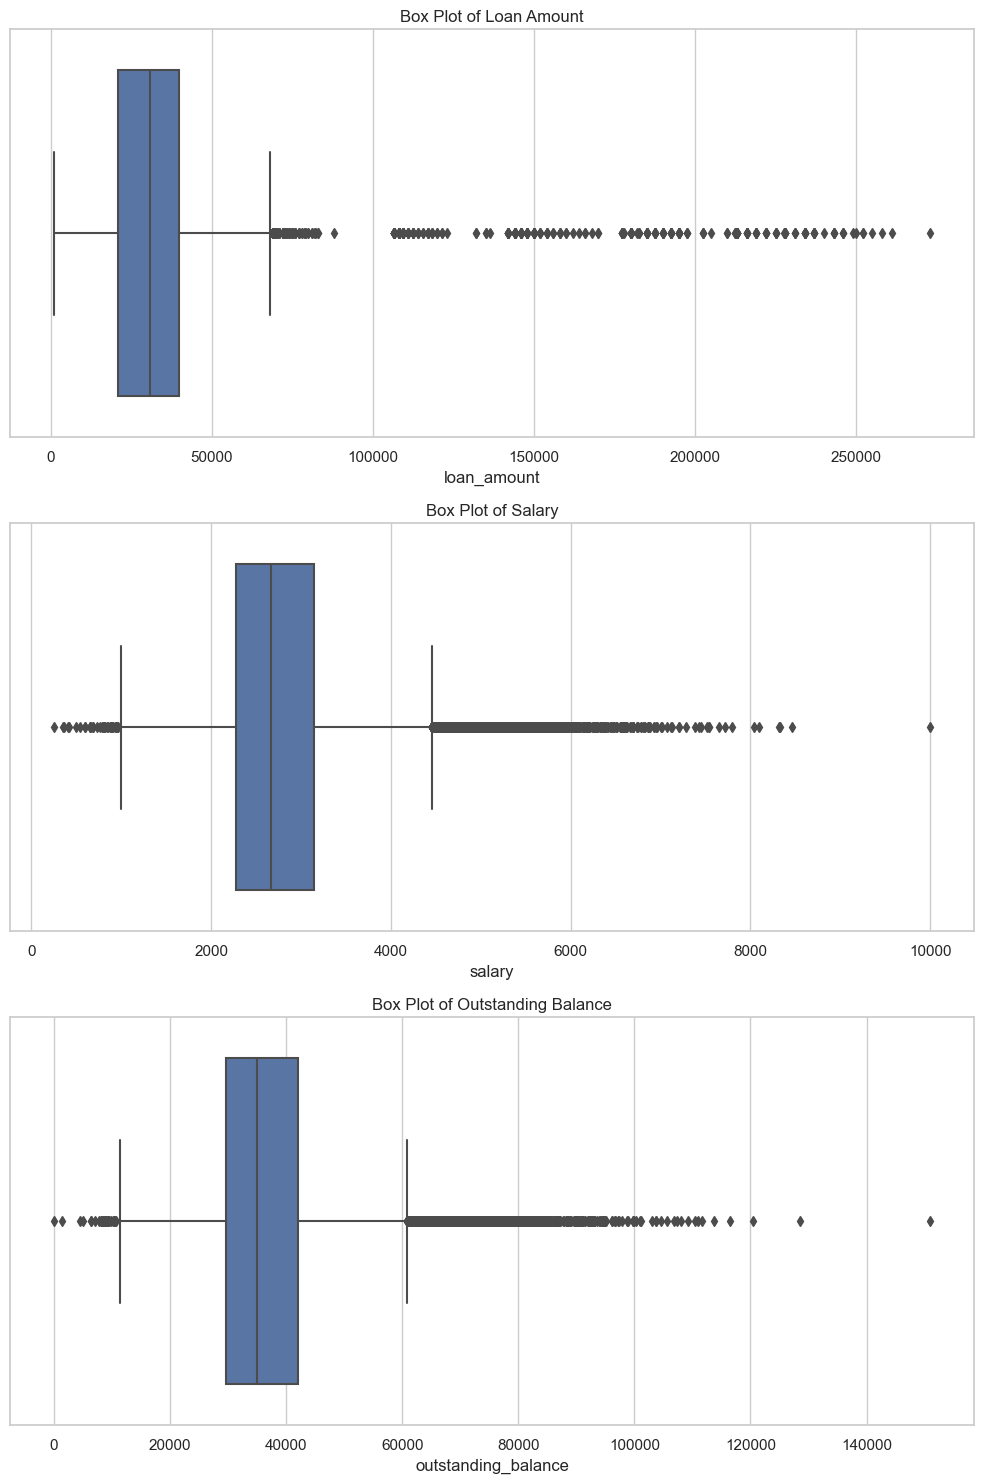

In [27]:
# checking for outliers in the columns: loan amount, salary and outstanding balance 
# Set the style for the plots
sns.set(style="whitegrid")

# Create a figure with subplots
fig, axes = plt.subplots(3, 1, figsize=(10, 15))

# Box plot for loan_amount
sns.boxplot(x=data['loan_amount'], ax=axes[0])
axes[0].set_title('Box Plot of Loan Amount')

# Box plot for salary
sns.boxplot(x=data['salary'], ax=axes[1])
axes[1].set_title('Box Plot of Salary')

# Box plot for outstanding_balance
sns.boxplot(x=data['outstanding_balance'], ax=axes[2])
axes[2].set_title('Box Plot of Outstanding Balance')

# Show the plots
plt.tight_layout()
plt.show()

In [28]:
# statistical method of detecting outliers 
# Function to identify outliers using IQR
def find_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers

# Finding outliers for each column
loan_amount_outliers = find_outliers_iqr(data, 'loan_amount')
salary_outliers = find_outliers_iqr(data, 'salary')
outstanding_balance_outliers = find_outliers_iqr(data, 'outstanding_balance')

# Display the number of outliers found
print(f'Number of outliers in loan_amount: {len(loan_amount_outliers)}')
print(f'Number of outliers in salary: {len(salary_outliers)}')
print(f'Number of outliers in outstanding_balance: {len(outstanding_balance_outliers)}')

# Optionally, display the outliers
print('Outliers in loan_amount:')
print(loan_amount_outliers)

print('Outliers in salary:')
print(salary_outliers)

print('Outliers in outstanding_balance:')
print(outstanding_balance_outliers)


Number of outliers in loan_amount: 507
Number of outliers in salary: 2580
Number of outliers in outstanding_balance: 2746
Outliers in loan_amount:
       gender disbursemet_date currency   country  is_employed  \
362      male       2023 03 21      USD  Zimbabwe         True   
764      male       2022 04 24      USD  Zimbabwe         True   
1178    other       2021 12 28      USD  Zimbabwe         True   
1259     male       2022 09 04      USD  Zimbabwe         True   
1319     male       2021 01 31      USD  Zimbabwe         True   
1355     male       2021 09 12      USD  Zimbabwe         True   
1742     male       2022 10 13      USD  Zimbabwe         True   
1750     male       2021 04 30      USD  Zimbabwe         True   
1938     male       2020 06 01      USD  Zimbabwe         True   
2272     male       2020 06 27      USD  Zimbabwe         True   
2388     male       2023 04 23      USD  Zimbabwe         True   
2504   female       2023 11 24      USD  Zimbabwe         Tru

       gender disbursemet_date currency   country  is_employed  \
19     female       2020 04 14      USD  Zimbabwe         True   
42     female       2022 09 27      USD  Zimbabwe         True   
117      male       2021 02 19      USD  Zimbabwe         True   
131    female       2023 03 19      USD  Zimbabwe         True   
222    female       2020 12 14      USD  Zimbabwe         True   
252      male       2020 05 17      USD  Zimbabwe         True   
296    female       2023 02 03      USD  Zimbabwe         True   
366     other       2021 08 13      USD  Zimbabwe         True   
389      male       2021 06 17      USD  Zimbabwe         True   
412    female       2023 05 22      USD  Zimbabwe         True   
418      male       2020 06 17      USD  Zimbabwe         True   
443      male       2021 08 15      USD  Zimbabwe         True   
487    female       2022 06 08      USD  Zimbabwe         True   
522      male       2022 01 23      USD  Zimbabwe         True   
538    fem

       gender disbursemet_date currency   country  is_employed  \
9        male       2020 12 03      USD  Zimbabwe         True   
49       male       2023 07 07      USD  Zimbabwe         True   
65     female       2022 07 12      USD  Zimbabwe         True   
167      male       2021 09 16      USD  Zimbabwe         True   
222    female       2020 12 14      USD  Zimbabwe         True   
261    female       2023 06 19      USD  Zimbabwe         True   
284    female       2023 06 07      USD  Zimbabwe         True   
314      male       2020 02 19      USD  Zimbabwe        False   
335     other       2020 03 28      USD  Zimbabwe         True   
537     other       2022 01 01      USD  Zimbabwe         True   
544    female       2021 03 27      USD  Zimbabwe         True   
552    female       2021 09 18      USD  Zimbabwe         True   
561    female       2020 06 26      USD  Zimbabwe         True   
655    female       2021 05 06      USD  Zimbabwe         True   
694    fem

## capping the outliers to reduce the impact of outliers while maintaining the size of the dataset

In [29]:
# Cap outliers using IQR method
def cap_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    data[column] = data[column].apply(lambda x: lower_bound if x < lower_bound else upper_bound if x > upper_bound else x)
    return data

data_capped = data.copy()
data_capped = cap_outliers_iqr(data_capped, 'loan_amount')
data_capped = cap_outliers_iqr(data_capped, 'salary')
data_capped = cap_outliers_iqr(data_capped, 'outstanding_balance')

print(f'Dataset size after capping outliers: {data_capped.shape}')


Dataset size after capping outliers: (100000, 16)


However, the outliers were not dropped as the data points were treated as legitimate values There is probably a good story to tell about this cohort of partipants than treating then as outliers and dropping them off or treating them otherwise in the dataset

In [30]:
# Check unique values in 'remaining term' column
print(data['remaining term'].unique())


['47' '62' '57' '42' '45' '44' '52' '46' '43' '50' '68' '49' '54' '58'
 '30' '81' '75' '71' '63' '48' '51' '41' '64' '69' '39' '67' '83' '66'
 '56' '55' '61' '35' '77' '53' '72' '25' '36' '40' '80' '52   ' '59' '32'
 '65' '54   ' '34' '60' '69_' '74' '84' '41_' '78' '55   ' '73' '86' '37'
 '34_' '60   ' '89' '38' '76' '14' '53_' '70' '58_' '65   ' '49   ' '26'
 '58   ' '62   ' '33' '28' '27' '82' '38_' '47_' '57_' '22' '85' '56   '
 '61   ' '52_' '44_' '45_' '51_' '73   ' '31' '63   ' '29' '65_' '48_'
 '47   ' '11' '40   ' '64   ' '87' '39_' '53   ' '59_' '64_' '33_' '92'
 '61_' '51   ' '18' '62_' '21' '39   ' '42   ' '59   ' '71   ' '50_'
 '82   ' '78_' '79' '55_' '56_' '23' '67   ' '57   ' '49_' '17' '20' '46_'
 '45   ' '24' '29_' '91' '68_' '93' '43   ' '50   ' '69   ' '38   '
 '48   ' '68   ' '88' '67_' '74_' '100' '42_' '76   ' '60_' '90' '30_'
 '72_' '66_' '31_' '46   ' '97' '54_' '34   ' '72   ' '32   ' '28_' '19'
 '102' '44   ' '112' '33   ' '15' '103' '105' '14_' '40_' '35_' '

In [31]:
# Clean 'remaining term' column to remove non-numeric characters and convert to int
data['remaining term'] = data['remaining term'].str.replace(r'\D+', '').astype(int)

# Check unique values again to verify
print(data['remaining term'].unique())

[ 47  62  57  42  45  44  52  46  43  50  68  49  54  58  30  81  75  71
  63  48  51  41  64  69  39  67  83  66  56  55  61  35  77  53  72  25
  36  40  80  59  32  65  34  60  74  84  78  73  86  37  89  38  76  14
  70  26  33  28  27  82  22  85  31  29  11  87  92  18  21  79  23  17
  20  24  91  93  88 100  90  97  19 102 112  15 103 105 116 107 120  13
  16  95 104 106   9 101 108  94  99  96  98 111   2  12   0  10   7   8
 114   5]


C:\Users\Tinotenda Mangarai\AppData\Local\Temp\ipykernel_6604\2595778798.py:2: FutureWarning: The default value of regex will change from True to False in a future version.
  data['remaining term'] = data['remaining term'].str.replace(r'\D+', '').astype(int)


In [32]:
# Converting 'disbursemet_date' to datetime format
data['disbursemet_date'] = pd.to_datetime(data['disbursemet_date'], format='%Y %m %d')
data.head()

,gender,disbursemet_date,currency,country,is_employed,job,location,loan_amount,number_of_defaults,outstanding_balance,interest_rate,age,remaining term,salary,marital_status,Loan Status
0,female,2022-10-29,USD,Zimbabwe,True,Teacher,Beitbridge,39000.0,0,48653.011473,0.22,37,47,3230.038869,married,Did not default
1,other,2020-06-06,USD,Zimbabwe,True,Teacher,Harare,27000.0,2,28752.062237,0.20,43,62,3194.139103,single,Did not default
2,other,2023-09-29,USD,Zimbabwe,True,Nurse,Gweru,35000.0,1,44797.554126,0.22,43,57,3330.826656,married,Did not default
3,female,2022-06-22,USD,Zimbabwe,True,Doctor,Rusape,24000.0,0,35681.496413,0.23,47,42,2246.797020,divorced,Did not default
4,male,2023-02-08,USD,Zimbabwe,True,Nurse,Chipinge,19000.0,0,34156.055882,0.20,42,45,2310.858441,married,Did not default


# EDA

In [33]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 16 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   gender               100000 non-null  object        
 1   disbursemet_date     100000 non-null  datetime64[ns]
 2   currency             100000 non-null  object        
 3   country              100000 non-null  object        
 4   is_employed          100000 non-null  bool          
 5   job                  100000 non-null  object        
 6   location             100000 non-null  object        
 7   loan_amount          100000 non-null  float64       
 8   number_of_defaults   100000 non-null  int64         
 9   outstanding_balance  100000 non-null  float64       
 10  interest_rate        100000 non-null  float64       
 11  age                  100000 non-null  int64         
 12  remaining term       100000 non-null  int32         
 13  salary         

# The demographic characteritsics of borrowers

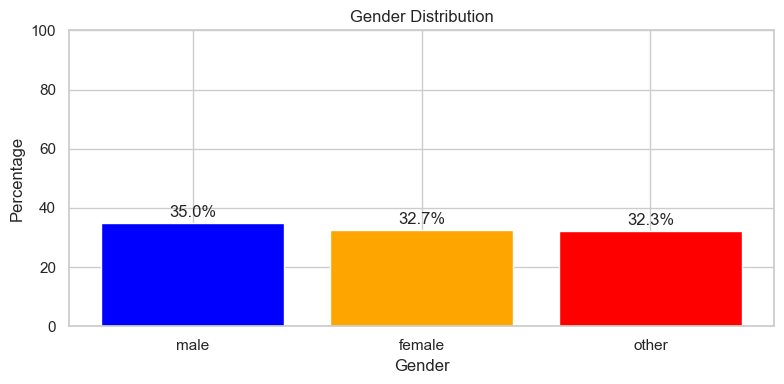

In [34]:
# Calculate percentage distribution of genders
gender_counts = data['gender'].value_counts(normalize=True) * 100

# Plotting
plt.figure(figsize=(8, 4))
bars = plt.bar(gender_counts.index, gender_counts.values, color=['blue', 'orange', 'red'])

# Adding labels with percentages
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f'{yval:.1f}%', ha='center', va='bottom')

# Adding titles and labels
plt.title('Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Percentage')
plt.ylim(0, 100)

# Show plot
plt.tight_layout()
plt.show()

from the results, there were slightly more male borrowers than females. There was also a significicant proportion of borrowers with unknown gender

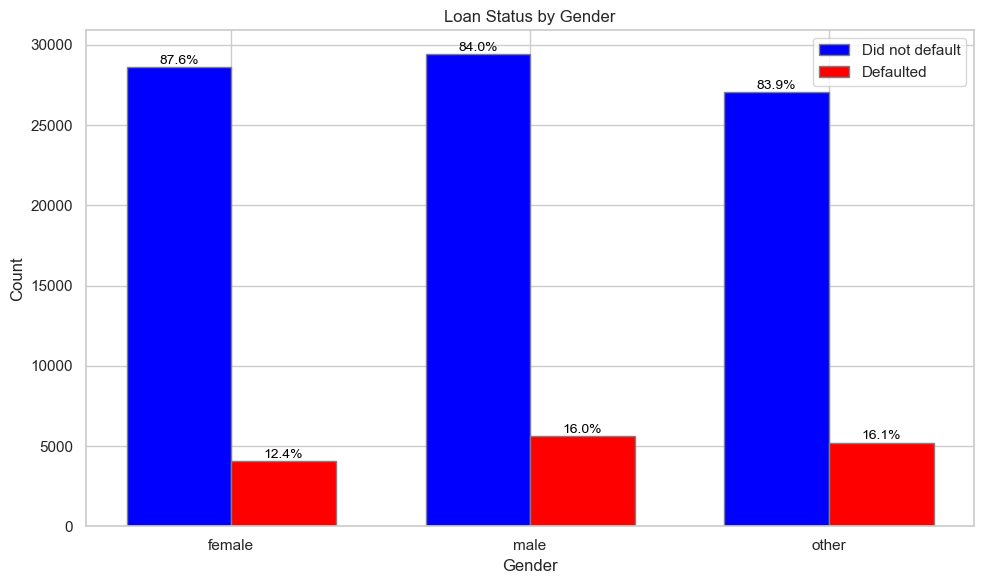

In [35]:
# Create separate counts for each loan status by gender
loan_status_counts = data.groupby(['gender', 'Loan Status']).size().unstack()

# Calculate percentages
total_gender = loan_status_counts.sum(axis=1)
percentages = loan_status_counts.div(total_gender, axis=0) * 100

# Plotting the clustered bar chart with percentages
plt.figure(figsize=(10, 6))

# Define bar width
bar_width = 0.35

# Positions of bars on X axis
r1 = range(len(loan_status_counts.index))
r2 = [x + bar_width for x in r1]

# Plot bars
plt.bar(r1, loan_status_counts['Did not default'], color='blue', width=bar_width, edgecolor='grey', label='Did not default')
plt.bar(r2, loan_status_counts['Defaulted'], color='red', width=bar_width, edgecolor='grey', label='Defaulted')

# Adding percentages on top of bars
for i, (p1, p2) in enumerate(zip(percentages['Did not default'], percentages['Defaulted'])):
    plt.text(r1[i], loan_status_counts['Did not default'][i] + 10, f'{p1:.1f}%', ha='center', va='bottom', fontsize=10, color='black')
    plt.text(r2[i], loan_status_counts['Defaulted'][i] + 10, f'{p2:.1f}%', ha='center', va='bottom', fontsize=10, color='black')

# Adding labels and titles
plt.xlabel('Gender')
plt.ylabel('Count')
plt.title('Loan Status by Gender')
plt.xticks([r + bar_width/2 for r in range(len(loan_status_counts.index))], loan_status_counts.index)

# Show plot with legend
plt.legend()
plt.tight_layout()
plt.show()


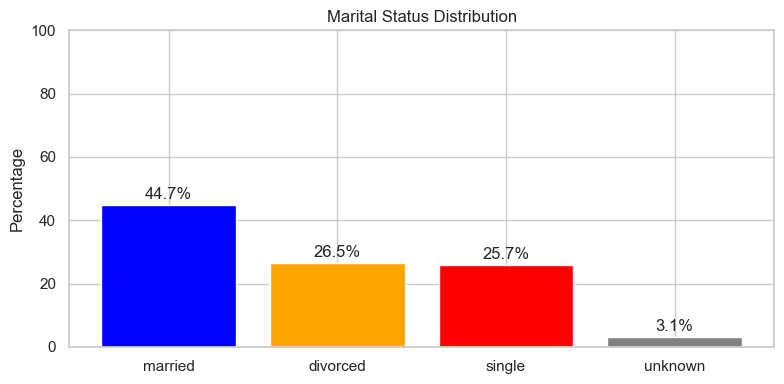

In [36]:
# Calculate percentage distribution of marital status 
ms_counts = data['marital_status'].value_counts(normalize=True) * 100

# Plotting
plt.figure(figsize=(8, 4))
bars = plt.bar(ms_counts.index, ms_counts.values, color=['blue', 'orange', 'red', 'gray'])

# Adding labels with percentages
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f'{yval:.1f}%', ha='center', va='bottom')

# Adding titles and labels
plt.title('Marital Status Distribution')
plt.xlabel('')
plt.ylabel('Percentage')
plt.ylim(0, 100)

# Show plot
plt.tight_layout()
plt.show()

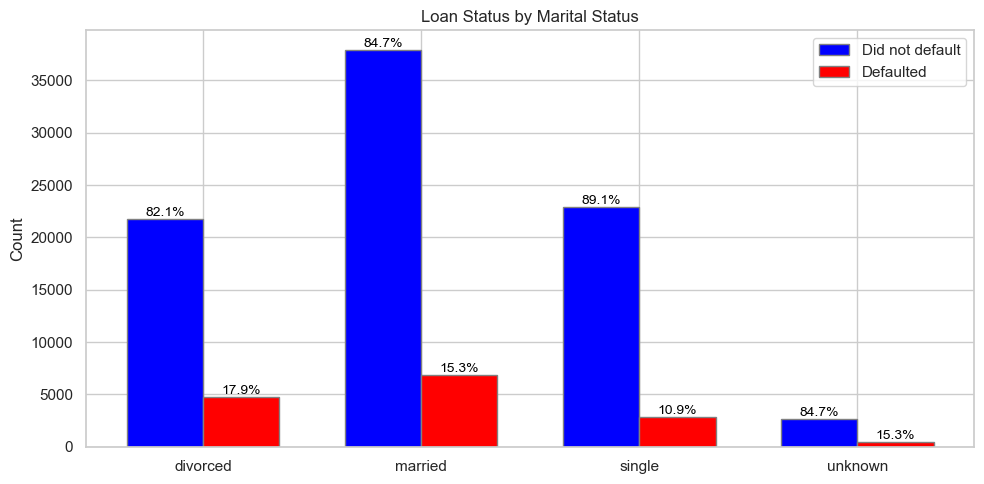

In [37]:
# Create separate counts for each loan status by marital_status
loan_status_counts = data.groupby(['marital_status', 'Loan Status']).size().unstack()

# Calculate percentages
total_ms = loan_status_counts.sum(axis=1)
percentages = loan_status_counts.div(total_ms, axis=0) * 100

# Plotting the clustered bar chart with percentages
plt.figure(figsize=(10, 5))

# Define bar width
bar_width = 0.35

# Positions of bars on X axis
r1 = range(len(loan_status_counts.index))
r2 = [x + bar_width for x in r1]

# Plot bars
plt.bar(r1, loan_status_counts['Did not default'], color='blue', width=bar_width, edgecolor='grey', label='Did not default')
plt.bar(r2, loan_status_counts['Defaulted'], color='red', width=bar_width, edgecolor='grey', label='Defaulted')

# Adding percentages on top of bars
for i, (p1, p2) in enumerate(zip(percentages['Did not default'], percentages['Defaulted'])):
    plt.text(r1[i], loan_status_counts['Did not default'][i] + 10, f'{p1:.1f}%', ha='center', va='bottom', fontsize=10, color='black')
    plt.text(r2[i], loan_status_counts['Defaulted'][i] + 10, f'{p2:.1f}%', ha='center', va='bottom', fontsize=10, color='black')

# Adding labels and titles
plt.xlabel('')
plt.ylabel('Count')
plt.title('Loan Status by Marital Status')
plt.xticks([r + bar_width/2 for r in range(len(loan_status_counts.index))], loan_status_counts.index)

# Show plot with legend
plt.legend()
plt.tight_layout()
plt.show()


The majority of individuals who did not default on their loans are married, at 84.7% of the non-defaulted population. For those who defaulted on their loans, the largest group is single individuals at 15.3% of the defaulted population. 

Divorced individuals have the highest default rate, with 17.9% of the divorced population defaulting on their loans. Single individuals have the second highest default rate, at 10.9% of the single population defaulting. 

Married individuals have the lowest default rate, with only 15.3% of the married population defaulting on their loans. 

The "unknown" marital status category has the lowest non-default rate at 84.7%, suggesting this group may be more prone to defaulting compared to the other marital status categories.

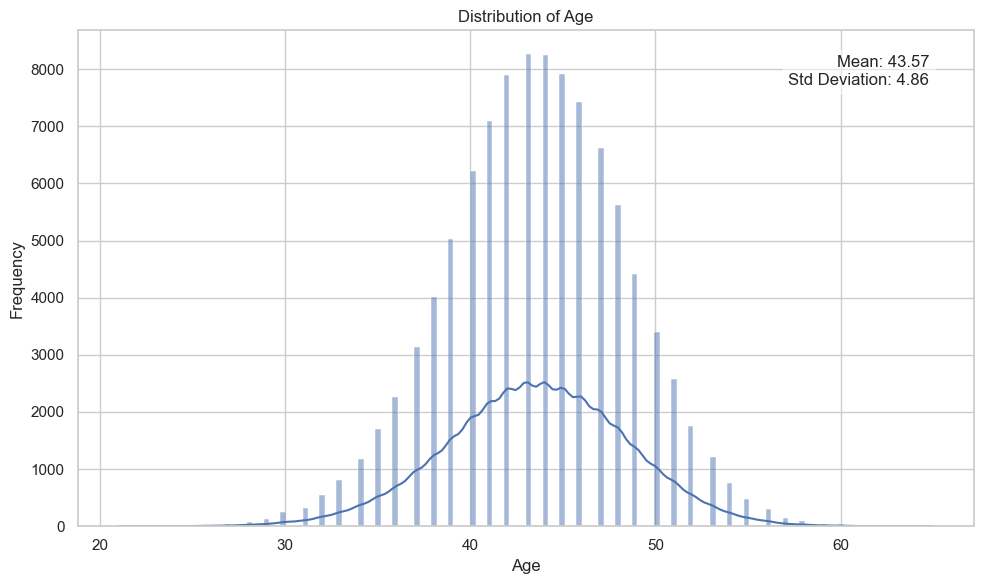

In [38]:
# Plotting histogram and KDE
plt.figure(figsize=(10, 6))
sns.histplot(data['age'], kde=True)

# Calculate mean and standard deviation
mean_age = data['age'].mean()
std_age = data['age'].std()

# Adding text for mean and std deviation
plt.text(x=0.95, y=0.95, transform=plt.gca().transAxes,
         s=f'Mean: {mean_age:.2f}\nStd Deviation: {std_age:.2f}',
         ha='right', va='top', fontsize=12, bbox=dict(facecolor='white', alpha=0.5))

# Adding titles and labels
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')

# Show plot
plt.tight_layout()
plt.show()

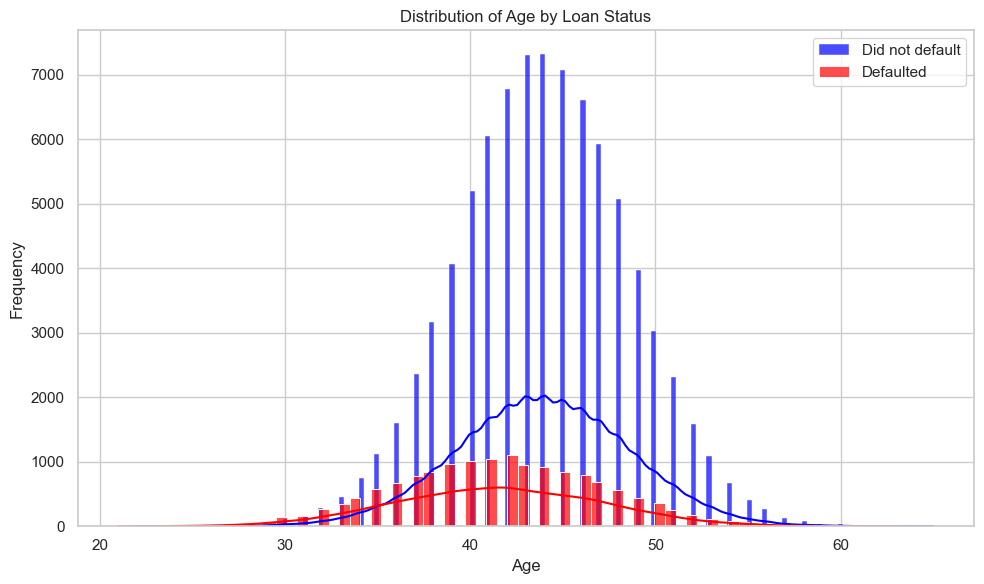

In [39]:
# Plotting histograms and KDEs by loan status
plt.figure(figsize=(10, 6))

# Plot for 'Did not default'
sns.histplot(data=data[data['Loan Status'] == 'Did not default'], x='age', kde=True, color='blue', label='Did not default', alpha=0.7)

# Plot for 'Defaulted'
sns.histplot(data=data[data['Loan Status'] == 'Defaulted'], x='age', kde=True, color='red', label='Defaulted', alpha=0.7)

# Adding titles and labels
plt.title('Distribution of Age by Loan Status')
plt.xlabel('Age')
plt.ylabel('Frequency')

# Show plot with legend
plt.legend()
plt.tight_layout()
plt.show()

The number of individuals who did not default peaks around ages 40-50, with a very high frequency compared to other age groups. This suggests that middle-aged individuals are more likely to successfully repay their loans. 

The default rate is generally lower for older individuals, with their line declining significantly after age 50. This suggests that as people age, they are less likely to default on their loans.

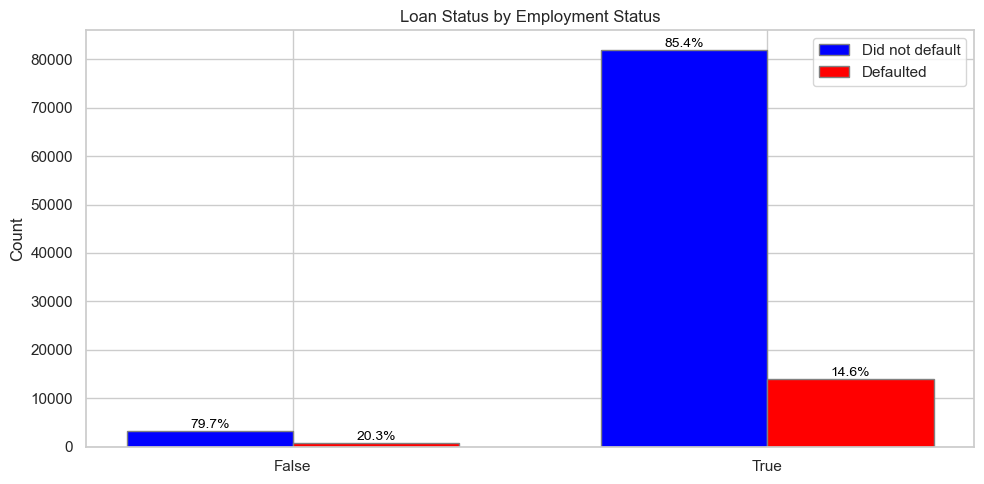

In [42]:
# Create separate counts for each loan status by employment status
loan_status_counts = data.groupby(['is_employed', 'Loan Status']).size().unstack()

# Calculate percentages
total_ms = loan_status_counts.sum(axis=1)
percentages = loan_status_counts.div(total_ms, axis=0) * 100

# Plotting the clustered bar chart with percentages
plt.figure(figsize=(10, 5))

# Define bar width
bar_width = 0.35

# Positions of bars on X axis
r1 = range(len(loan_status_counts.index))
r2 = [x + bar_width for x in r1]

# Plot bars
plt.bar(r1, loan_status_counts['Did not default'], color='blue', width=bar_width, edgecolor='grey', label='Did not default')
plt.bar(r2, loan_status_counts['Defaulted'], color='red', width=bar_width, edgecolor='grey', label='Defaulted')

# Adding percentages on top of bars
for i, (p1, p2) in enumerate(zip(percentages['Did not default'], percentages['Defaulted'])):
    plt.text(r1[i], loan_status_counts['Did not default'][i] + 10, f'{p1:.1f}%', ha='center', va='bottom', fontsize=10, color='black')
    plt.text(r2[i], loan_status_counts['Defaulted'][i] + 10, f'{p2:.1f}%', ha='center', va='bottom', fontsize=10, color='black')

# Adding labels and titles
plt.xlabel('')
plt.ylabel('Count')
plt.title('Loan Status by Employment Status')
plt.xticks([r + bar_width/2 for r in range(len(loan_status_counts.index))], loan_status_counts.index)

# Show plot with legend
plt.legend()
plt.tight_layout()
plt.show()


The majority of individuals (85.4%) who did not default on their loans were employed. In contrast, only 79.7% of those unemployed did no default on their loans. The default rate is significantly higher for those not employed, at 20.3%, compared to only 14.6% for those employed (14.6%)

In [43]:
data["currency"].value_counts(normalize=True)

USD    1.0
Name: currency, dtype: float64

there was only once currency. no need for further analysis. This also indicates that it was not necessary to include in modelling phase

In [44]:
data["country"].value_counts(normalize=True)

Zimbabwe    1.0
Name: country, dtype: float64

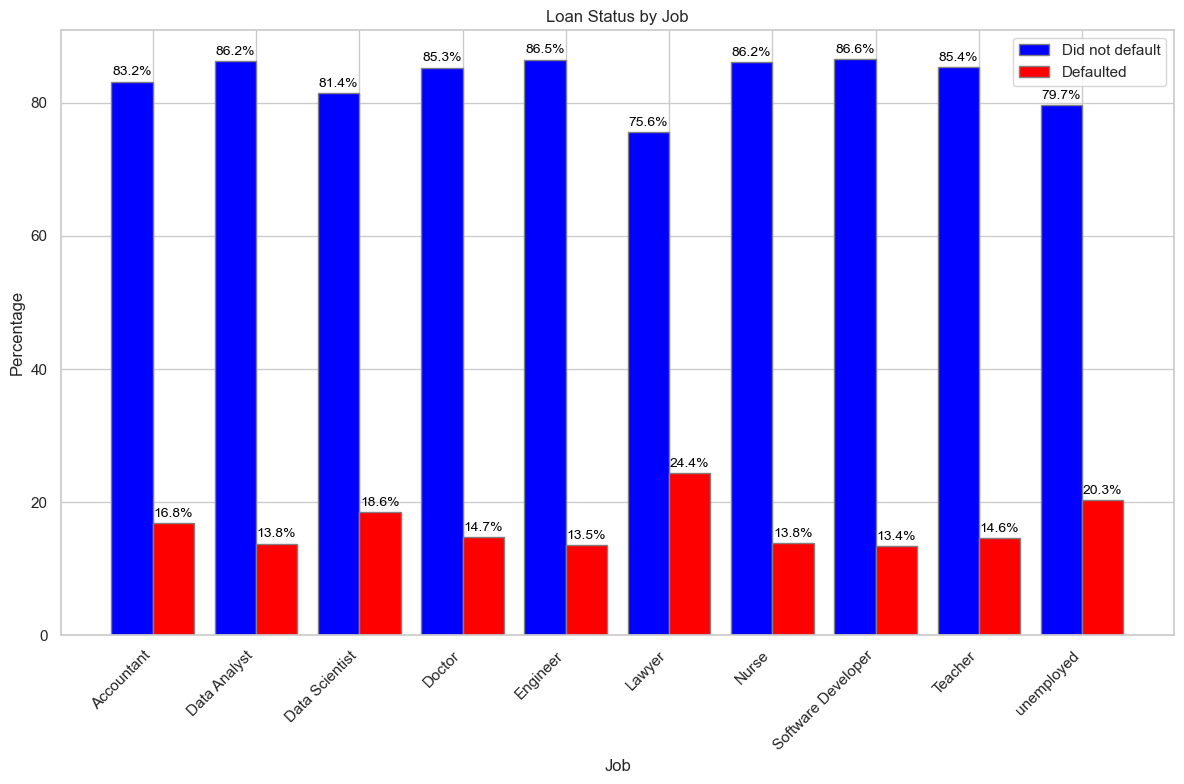

In [45]:
# Create a cross-tabulation of loan status by job
loan_status_job = pd.crosstab(data['job'], data['Loan Status'])

# Calculate percentages
total_job = loan_status_job.sum(axis=1)
percentages = loan_status_job.div(total_job, axis=0) * 100

# Plotting the clustered bar chart with percentages
plt.figure(figsize=(12, 8))

# Define bar width
bar_width = 0.4

# Positions of bars on X axis
r1 = range(len(percentages))
r2 = [x + bar_width for x in r1]

# Plot bars for 'Did not default'
plt.bar(r1, percentages['Did not default'], color='blue', width=bar_width, edgecolor='grey', label='Did not default')

# Plot bars for 'Defaulted'
plt.bar(r2, percentages['Defaulted'], color='red', width=bar_width, edgecolor='grey', label='Defaulted')

# Adding percentages on top of bars
for i, (p1, p2) in enumerate(zip(percentages['Did not default'], percentages['Defaulted'])):
    plt.text(r1[i], p1 + 0.5, f'{p1:.1f}%', ha='center', va='bottom', fontsize=10, color='black')
    plt.text(r2[i], p2 + 0.5, f'{p2:.1f}%', ha='center', va='bottom', fontsize=10, color='black')

# Adding labels and titles
plt.xlabel('Job')
plt.ylabel('Percentage')
plt.title('Loan Status by Job')
plt.xticks([r + bar_width/2 for r in range(len(percentages))], percentages.index, rotation=45, ha='right')

# Show plot with legend
plt.legend()
plt.tight_layout()
plt.show()

The job categories with the highest percentage of individuals who did not default on their loans are Software Developer (86.8%), Nurse (86.2%), and Data Analyst (86.2%).

The job categories with the highest default rates are lawyer (24.4%), Data Scientist (18.6%), and Accountant (16.8%).

The job categories with the lowest default rates are oftware Developer (13.4%), Nurse (13.8%), and Data Analyst (13.8%).

Among the unemployed, a high proportion of the clients did not default and only 20.3% defaulted

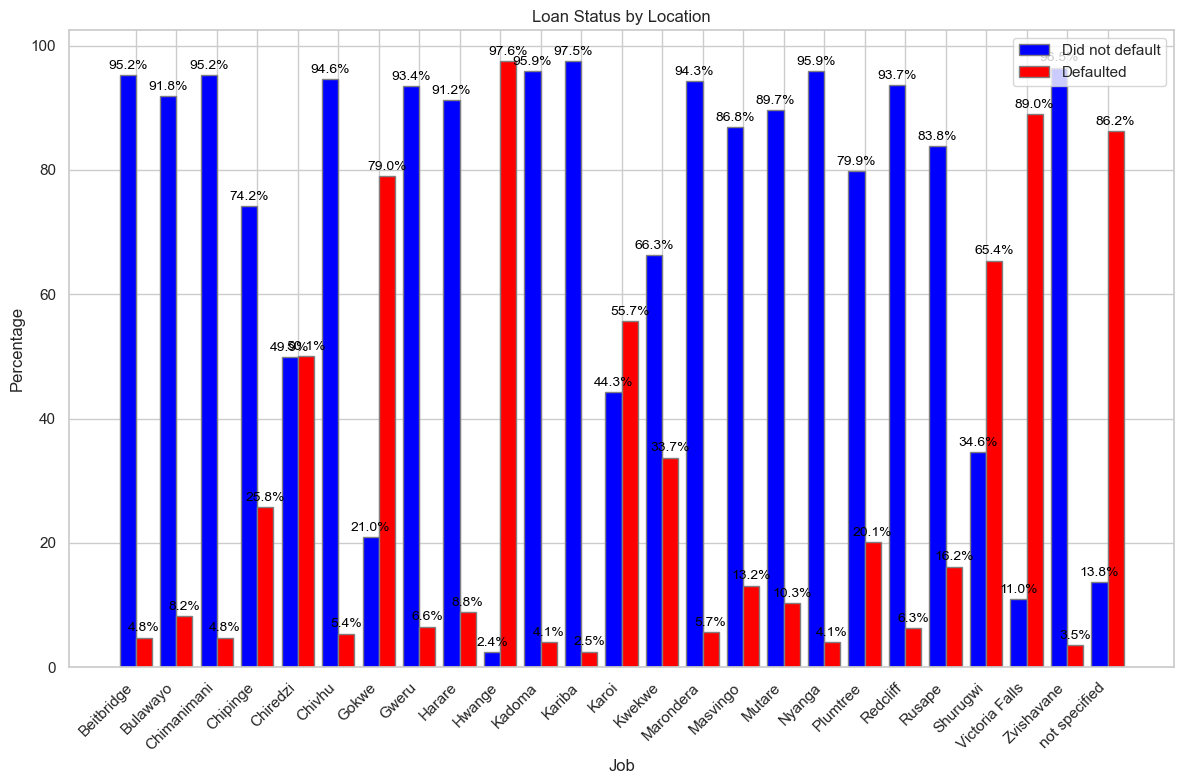

In [46]:
# Create a cross-tabulation of loan status by job
loan_status_job = pd.crosstab(data['location'], data['Loan Status'])

# Calculate percentages
total_job = loan_status_job.sum(axis=1)
percentages = loan_status_job.div(total_job, axis=0) * 100

# Plotting the clustered bar chart with percentages
plt.figure(figsize=(12, 8))

# Define bar width
bar_width = 0.4

# Positions of bars on X axis
r1 = range(len(percentages))
r2 = [x + bar_width for x in r1]

# Plot bars for 'Did not default'
plt.bar(r1, percentages['Did not default'], color='blue', width=bar_width, edgecolor='grey', label='Did not default')

# Plot bars for 'Defaulted'
plt.bar(r2, percentages['Defaulted'], color='red', width=bar_width, edgecolor='grey', label='Defaulted')

# Adding percentages on top of bars
for i, (p1, p2) in enumerate(zip(percentages['Did not default'], percentages['Defaulted'])):
    plt.text(r1[i], p1 + 0.5, f'{p1:.1f}%', ha='center', va='bottom', fontsize=10, color='black')
    plt.text(r2[i], p2 + 0.5, f'{p2:.1f}%', ha='center', va='bottom', fontsize=10, color='black')

# Adding labels and titles
plt.xlabel('Job')
plt.ylabel('Percentage')
plt.title('Loan Status by Location')
plt.xticks([r + bar_width/2 for r in range(len(percentages))], percentages.index, rotation=45, ha='right')

# Show plot with legend
plt.legend()
plt.tight_layout()
plt.show()

The locations with the highest percentage of individuals who did not default on their loans are Kariba, Kadoma, Nyanga, Chimanimanu, and Beitbridge. These appear to be relatively high-performing areas in terms of loan repayment. The locations with the highest default rates are Hwange, Victoria Falls, Gokwe, Shurugwi and Karoi (83.8%). These seem to be the areas where individuals are more prone to defaulting on their loans. This shows that location is a significant predictor

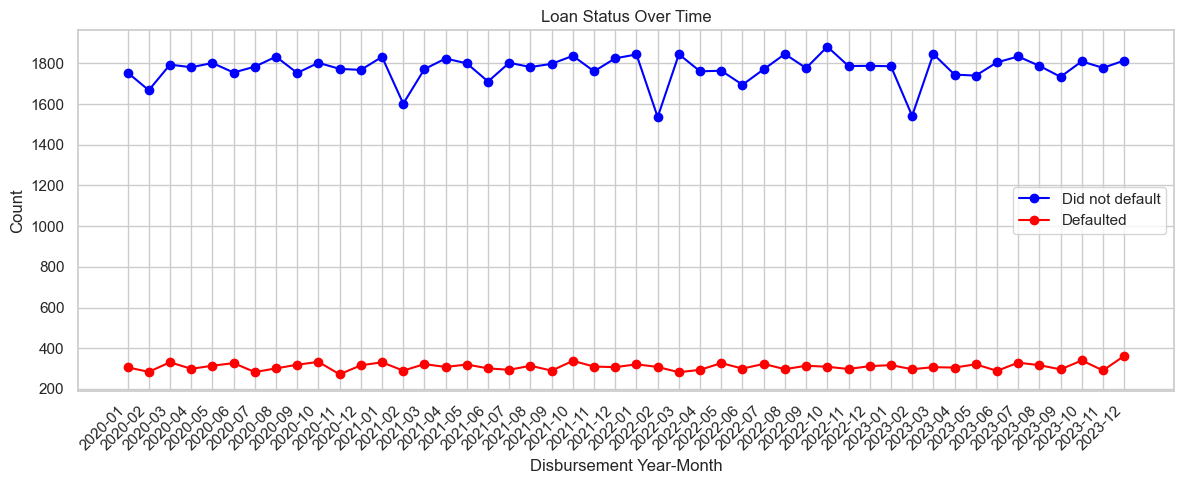

In [47]:
# Create 'disbursement_year_month' column
data['disbursement_year_month'] = data['disbursemet_date'].dt.to_period('M')

# Create a cross-tabulation of loan status by disbursement year and month
loan_status_date = pd.crosstab(data['disbursement_year_month'], data['Loan Status'])

# Plotting the line chart
plt.figure(figsize=(12, 5))

# Plot 'Did not default' as a line
plt.plot(loan_status_date.index.astype(str), loan_status_date['Did not default'], marker='o', color='blue', label='Did not default')

# Plot 'Defaulted' as a line
plt.plot(loan_status_date.index.astype(str), loan_status_date['Defaulted'], marker='o', color='red', label='Defaulted')

# Adding labels and titles
plt.xlabel('Disbursement Year-Month')
plt.ylabel('Count')
plt.title('Loan Status Over Time')
plt.xticks(rotation=45, ha='right')

# Show plot with legend
plt.legend()
plt.tight_layout()
plt.show()

There are distinct seasonal patterns, where the number of both non-defaulted and defaulted loans tends to peak towards the end of each year (Q4) and then decrease in the following months. The gap between the blue and red lines widens over time, indicating that the proportion of loans that did not default is increasing compared to the proportion of defaulted loans. There are a few instances where defaulted loans spike, such as around 2021-09 and 2022-09, but these spikes are relatively short-lived.

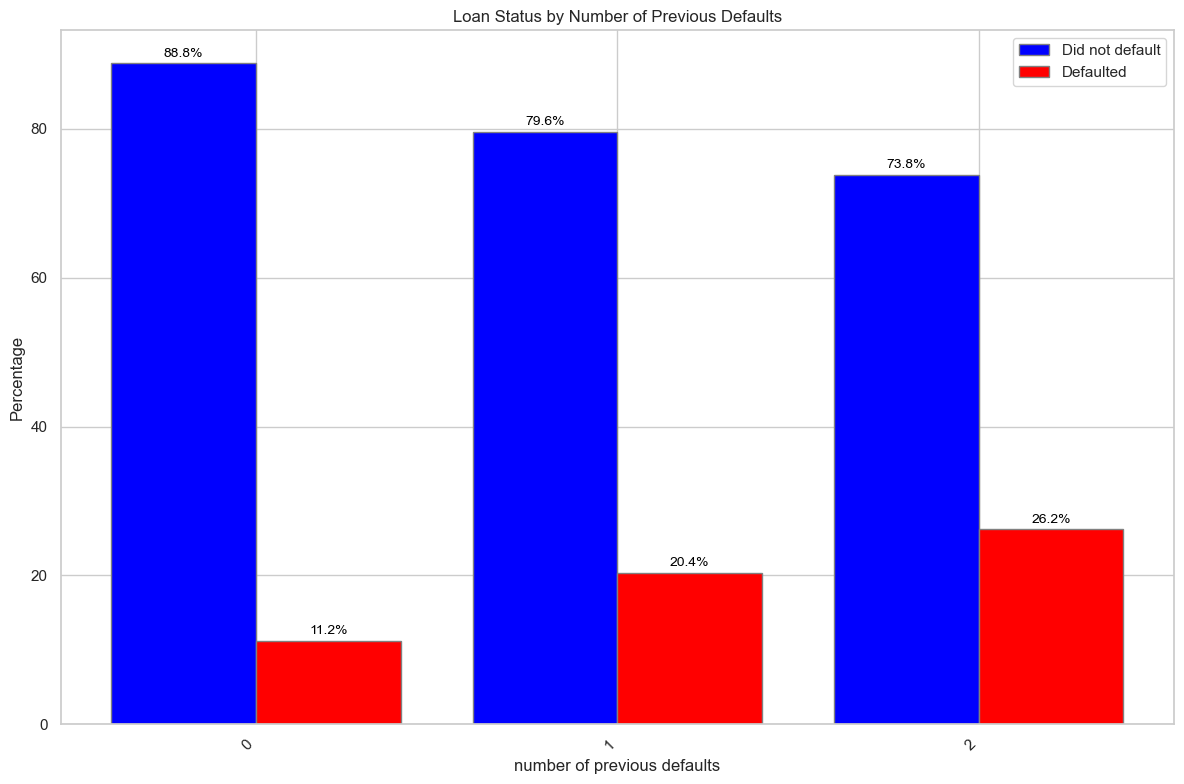

In [48]:
# Create a cross-tabulation of loan status by number_of_defaults
loan_status_job = pd.crosstab(data['number_of_defaults'], data['Loan Status'])

# Calculate percentages
total_job = loan_status_job.sum(axis=1)
percentages = loan_status_job.div(total_job, axis=0) * 100

# Plotting the clustered bar chart with percentages
plt.figure(figsize=(12, 8))

# Define bar width
bar_width = 0.4

# Positions of bars on X axis
r1 = range(len(percentages))
r2 = [x + bar_width for x in r1]

# Plot bars for 'Did not default'
plt.bar(r1, percentages['Did not default'], color='blue', width=bar_width, edgecolor='grey', label='Did not default')

# Plot bars for 'Defaulted'
plt.bar(r2, percentages['Defaulted'], color='red', width=bar_width, edgecolor='grey', label='Defaulted')

# Adding percentages on top of bars
for i, (p1, p2) in enumerate(zip(percentages['Did not default'], percentages['Defaulted'])):
    plt.text(r1[i], p1 + 0.5, f'{p1:.1f}%', ha='center', va='bottom', fontsize=10, color='black')
    plt.text(r2[i], p2 + 0.5, f'{p2:.1f}%', ha='center', va='bottom', fontsize=10, color='black')

# Adding labels and titles
plt.xlabel('number of previous defaults')
plt.ylabel('Percentage')
plt.title('Loan Status by Number of Previous Defaults')
plt.xticks([r + bar_width/2 for r in range(len(percentages))], percentages.index, rotation=45, ha='right')

# Show plot with legend
plt.legend()
plt.tight_layout()
plt.show()

For borrowers with no previous defaults, the percentage that did not default is very high at 88.8%, while the default rate is only 11.2%.

For borrowers with 1 previous default, the percentage that did not default drops significantly to 79.6%, while the default rate increases to 20.4%.

For borrowers with 2 or more previous defaults, the trend continues, with the percentage that did not default further declining to 73.8%, and the default rate rising to 26.2%.

This data clearly demonstrates that the number of previous defaults is a strong predictor of future loan repayment behavior. Borrowers with a history of defaults are much more likely to default again compared to those with no prior defaults.

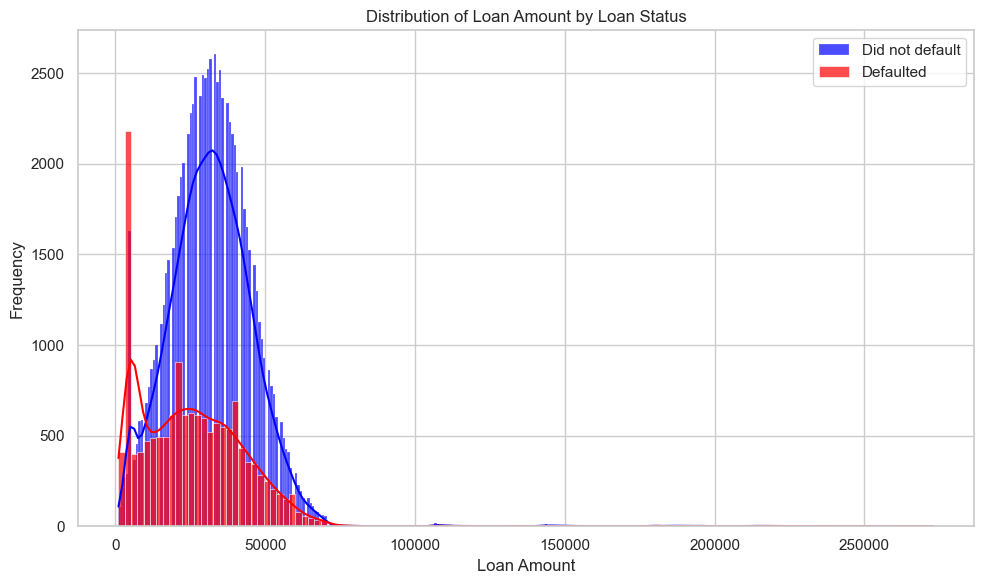

In [49]:
# Plotting the distribution of loan amount by loan status
plt.figure(figsize=(10, 6))

# Plot histogram for 'Did not default'
sns.histplot(data=data[data['Loan Status'] == 'Did not default'], x='loan_amount', kde=True, color='blue', label='Did not default', alpha=0.7)

# Plot histogram for 'Defaulted'
sns.histplot(data=data[data['Loan Status'] == 'Defaulted'], x='loan_amount', kde=True, color='red', label='Defaulted', alpha=0.7)

# Adding labels and titles
plt.title('Distribution of Loan Amount by Loan Status')
plt.xlabel('Loan Amount')
plt.ylabel('Frequency')

# Show plot with legend
plt.legend()
plt.tight_layout()
plt.show()

The distribution of loan amounts for loans that did not default has a bimodal shape, with a larger peak around  20,000−
 30,000 and a smaller peak around  150,000−
 160,000.

The distribution of loan amounts for defaulted loans has a peak around  10,000−
 15,000, indicating that defaulted loans tend to be smaller in size compared to non-defaulted loans.

There is a long tail in the distribution of non-defaulted loans, extending up to around $250,000, suggesting some borrowers take out larger loans that still manage to be repaid.

The peaks and shapes of the two distributions differ significantly, indicating that loan amount is an important factor in predicting loan default risk.

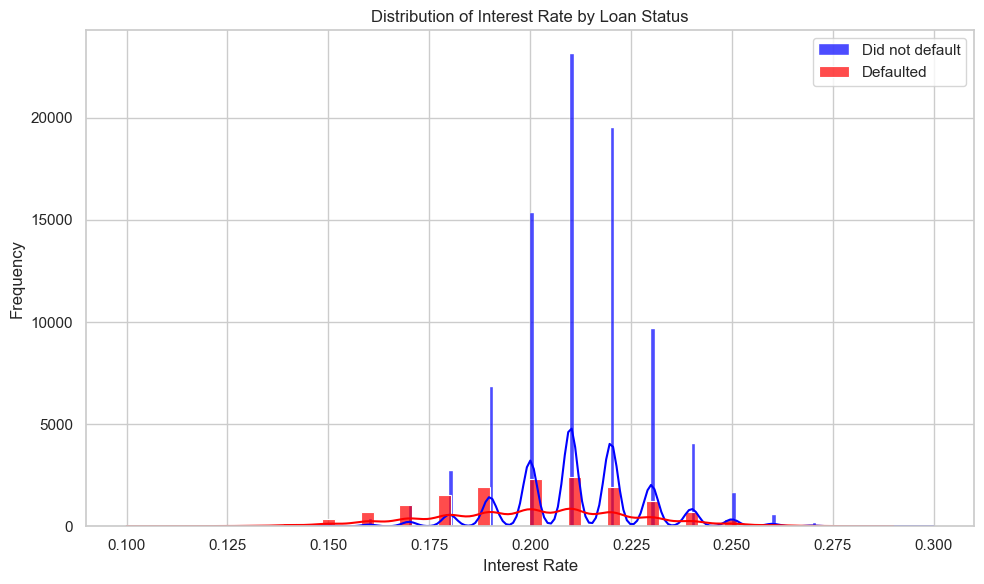

In [50]:
# Plotting the distribution of interest rate by loan status
plt.figure(figsize=(10, 6))

# Plot histogram for 'Did not default'
sns.histplot(data=data[data['Loan Status'] == 'Did not default'], x='interest_rate', kde=True, color='blue', label='Did not default', alpha=0.7)

# Plot histogram for 'Defaulted'
sns.histplot(data=data[data['Loan Status'] == 'Defaulted'], x='interest_rate', kde=True, color='red', label='Defaulted', alpha=0.7)

# Adding labels and titles
plt.title('Distribution of Interest Rate by Loan Status')
plt.xlabel('Interest Rate')
plt.ylabel('Frequency')

# Show plot with legend
plt.legend()
plt.tight_layout()
plt.show()

The distribution for loans that did not default is bimodal, with a large peak around 0.2 to 0.225 interest rate

The distribution for defaulted loans is unimodal, with a single peak around 0.24 (24% interest rate).

There are a few non-defaulted loans with interest rates as high as 27.5%

This analysis suggests that interest rate is an important factor in predicting loan default risk. Borrowers paying higher interest rates appear to be more prone to default compared to those with lower interest rates.

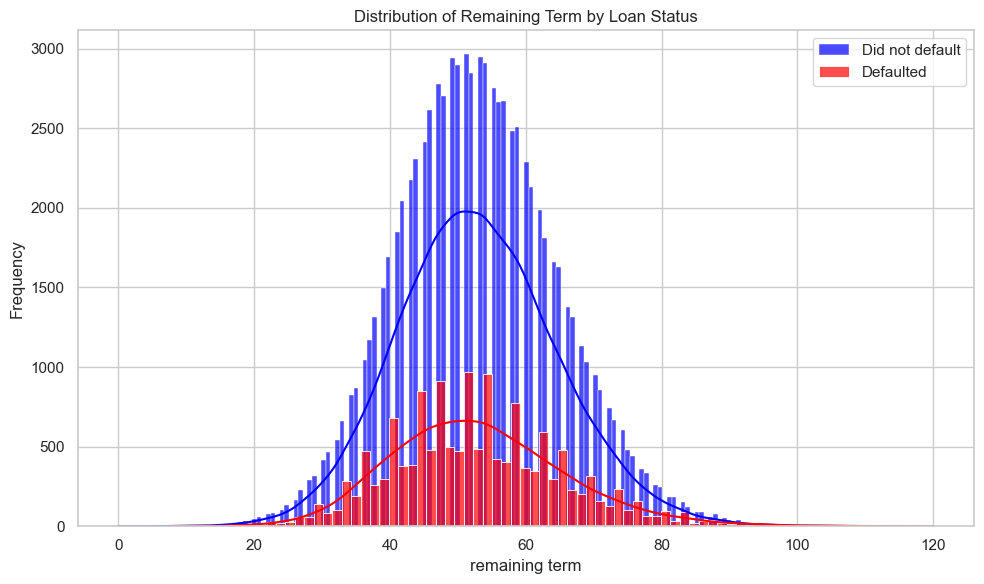

In [51]:
# Plotting the distribution of remaining term by loan status
plt.figure(figsize=(10, 6))

# Plot histogram for 'Did not default'
sns.histplot(data=data[data['Loan Status'] == 'Did not default'], x='remaining term', kde=True, color='blue', label='Did not default', alpha=0.7)

# Plot histogram for 'Defaulted'
sns.histplot(data=data[data['Loan Status'] == 'Defaulted'], x='remaining term', kde=True, color='red', label='Defaulted', alpha=0.7)

# Adding labels and titles
plt.title('Distribution of Remaining Term by Loan Status')
plt.xlabel('remaining term')
plt.ylabel('Frequency')

# Show plot with legend
plt.legend()
plt.tight_layout()
plt.show()

<Figure size 1200x600 with 0 Axes>

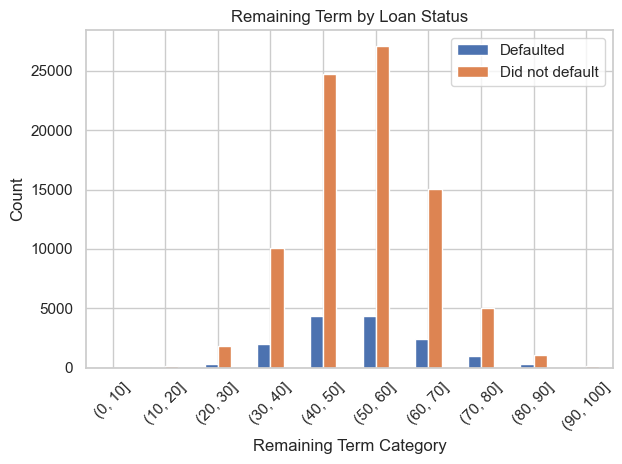

In [52]:
# Convert 'remaining term' column to integer
data['remaining term'] = data['remaining term'].astype(int)

# Create categories for remaining term
bins = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
data['remaining_term_category'] = pd.cut(data['remaining term'], bins=bins)

# Plot the bar graph
plt.figure(figsize=(12, 6))
ax = data.groupby(['remaining_term_category', 'Loan Status']).size().unstack(fill_value=0).plot(kind='bar')

# Add labels and title
plt.title('Remaining Term by Loan Status')
plt.xlabel('Remaining Term Category')
plt.ylabel('Count')
plt.xticks(rotation=45)

# Add legend
plt.legend()
plt.tight_layout()
plt.show()

The majority of loans, both defaulted and non-defaulted, fall into the 50-60 months and 40-50 remaining term category.

As the remaining term increases from 60 months, the proportion of defaulted loans was decreasing. Same with proprtion of not defaulted loans

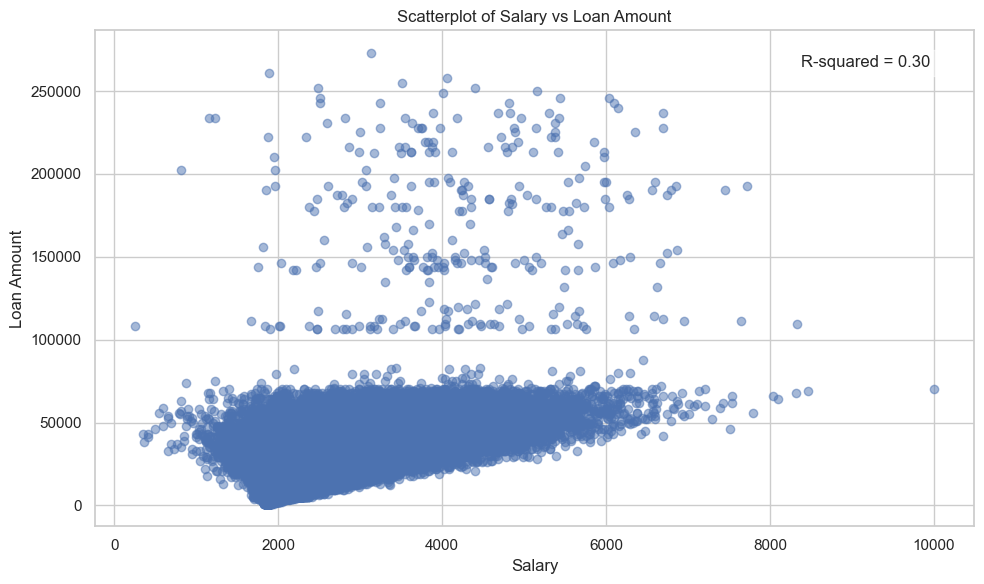

In [53]:
# Plotting the scatterplot
plt.figure(figsize=(10, 6))
plt.scatter(data['salary'], data['loan_amount'], alpha=0.5)

# Perform linear regression
model = LinearRegression()
X = data['salary'].values.reshape(-1, 1)
y = data['loan_amount'].values.reshape(-1, 1)
model.fit(X, y)

# Predicted values
y_pred = model.predict(X)

# Calculate R-squared
r2 = r2_score(y, y_pred)

# Adding R-squared on top right corner
plt.text(0.95, 0.95, f'R-squared = {r2:.2f}', ha='right', va='top', transform=plt.gca().transAxes,
         bbox=dict(facecolor='white', alpha=0.5), fontsize=12)

# Adding labels and title
plt.xlabel('Salary')
plt.ylabel('Loan Amount')
plt.title('Scatterplot of Salary vs Loan Amount')

# Show plot
plt.tight_layout()
plt.show()

There is a general upward trend, suggesting that as salary increases, the associated loan amount also tends to be higher.

However, the scatter of points is quite wide, indicating a fair amount of variability in the relationship. There are many data points that do not follow the overall positive trend.

The R-squared value of 0.30 means that only 30% of the variation in loan amount can be explained by the variation in salary. This suggests that other factors beyond just salary likely play a significant role in determining the loan amount.

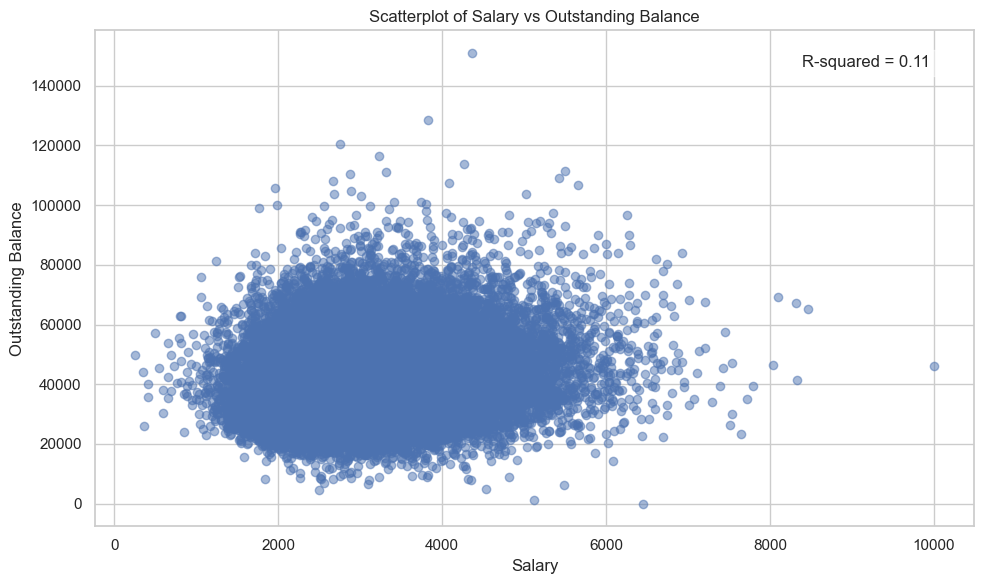

In [54]:
# Plotting the scatterplot
plt.figure(figsize=(10, 6))
plt.scatter(data['salary'], data['outstanding_balance'], alpha=0.5)

# Perform linear regression
model = LinearRegression()
X = data['salary'].values.reshape(-1, 1)
y = data['outstanding_balance'].values.reshape(-1, 1)
model.fit(X, y)

# Predicted values
y_pred = model.predict(X)

# Calculate R-squared
r2 = r2_score(y, y_pred)

# Adding R-squared on top right corner
plt.text(0.95, 0.95, f'R-squared = {r2:.2f}', ha='right', va='top', transform=plt.gca().transAxes,
         bbox=dict(facecolor='white', alpha=0.5), fontsize=12)

# Adding labels and title
plt.xlabel('Salary')
plt.ylabel('Outstanding Balance')
plt.title('Scatterplot of Salary vs Outstanding Balance')

# Show plot
plt.tight_layout()
plt.show()

There is a slightly positive trend, meaning as salary increases, the outstanding balance tends to be higher as well. However, the correlation is quite weak, as evidenced by the low R-squared value of 0.11.

The data points exhibit a wide scatter around the overall trend line, indicating that factors other than just salary play a significant role in determining the outstanding balance.

The distribution of points has an irregular, elongated shape rather than a clear linear or triangular pattern. This suggests the relationship between salary and outstanding balance is not straightforward.

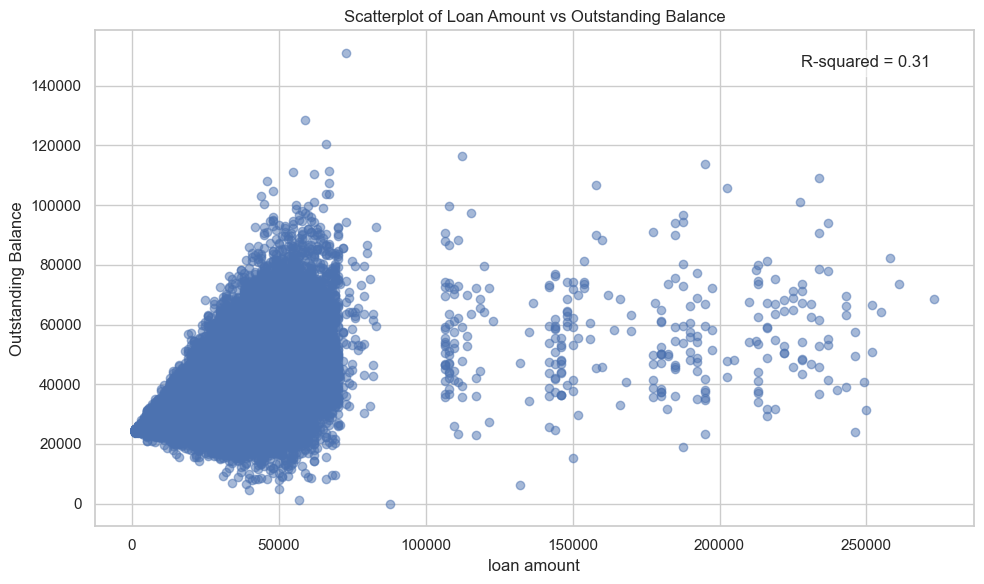

In [55]:
# Plotting the scatterplot
plt.figure(figsize=(10, 6))
plt.scatter(data['loan_amount'], data['outstanding_balance'], alpha=0.5)

# Perform linear regression
model = LinearRegression()
X = data['loan_amount'].values.reshape(-1, 1)
y = data['outstanding_balance'].values.reshape(-1, 1)
model.fit(X, y)

# Predicted values
y_pred = model.predict(X)

# Calculate R-squared
r2 = r2_score(y, y_pred)

# Adding R-squared on top right corner
plt.text(0.95, 0.95, f'R-squared = {r2:.2f}', ha='right', va='top', transform=plt.gca().transAxes,
         bbox=dict(facecolor='white', alpha=0.5), fontsize=12)

# Adding labels and title
plt.xlabel('loan amount')
plt.ylabel('Outstanding Balance')
plt.title('Scatterplot of Loan Amount vs Outstanding Balance')

# Show plot
plt.tight_layout()
plt.show()

There is a positive trend, meaning as the loan amount increases, the outstanding balance also tends to be higher. This aligns with the expectation that larger loans would lead to larger outstanding balances.

While the overall trend is positive, the data points exhibit a fair amount of variability and scatter around the trend line.

This indicates that factors other than just the loan amount also play a role in determining the outstanding balance.

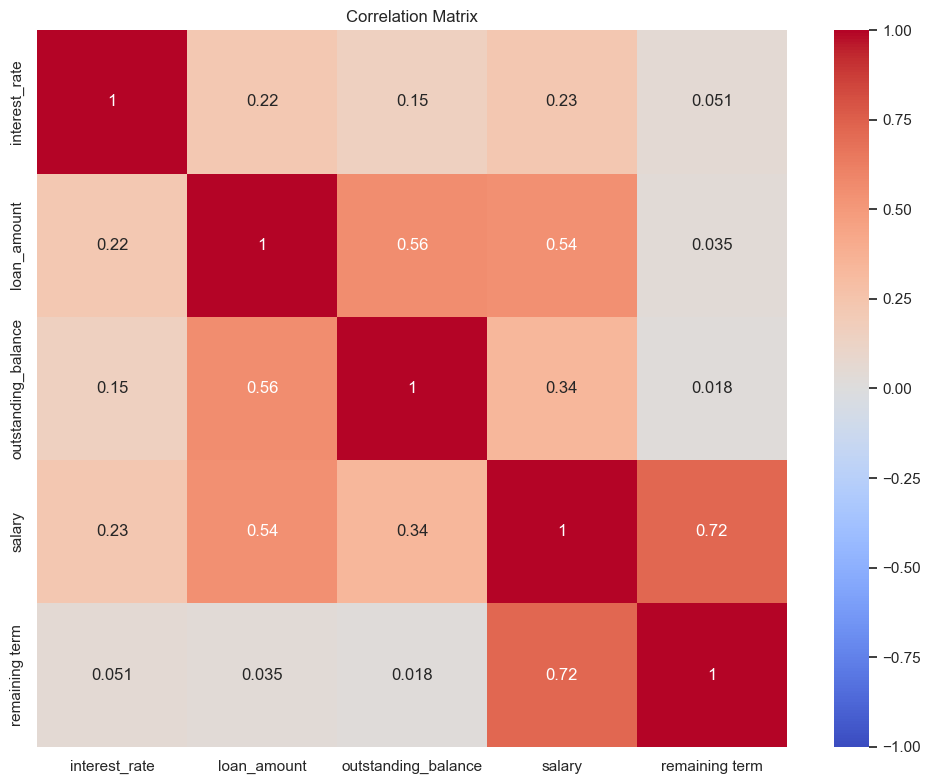

In [56]:
# Select columns of interest
columns_of_interest = ['interest_rate', 'loan_amount', 'outstanding_balance', 'salary', 'remaining term']

# Create a correlation matrix
correlation_matrix = data[columns_of_interest].corr()

# Plotting the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)

# Adding title
plt.title('Correlation Matrix')

# Show plot
plt.tight_layout()
plt.show()

The correlation matrix reveals that the strong positive relationships exist between salary and remaining term (0.72), moderate positive correlation between loan amount and outstanding balance and moderate positive correlation between loan amount and salary. The other correlations are relatively weak, indicating that the variables are not strongly linearly related to each other.

# Feature Selection using mutual information regression and SelectKBest methods

In [57]:
from sklearn.feature_selection import mutual_info_regression, SelectKBest, chi2
from sklearn.preprocessing import LabelEncoder

## To perform feature selection processes, label encoding is applied, a feature transformation technique.
the LabelEncoder from scikit-learn is used to transform the categorical columns 'gender', 'is_employed', 'job', 'location', and 'marital_status' into numerical labels.

The label encoding was used because:

Simplicity and Ease of Implementation: Label encoding is a straightforward and easy-to-implement technique, making it a popular choice for handling categorical variables in machine learning projects.

Preserving Ordinal Relationships: If the categorical variables have an inherent ordinal relationship (e.g., 'low', 'medium', 'high'), label encoding can preserve this order by assigning numerical values in the correct order (e.g., 0, 1, 2).

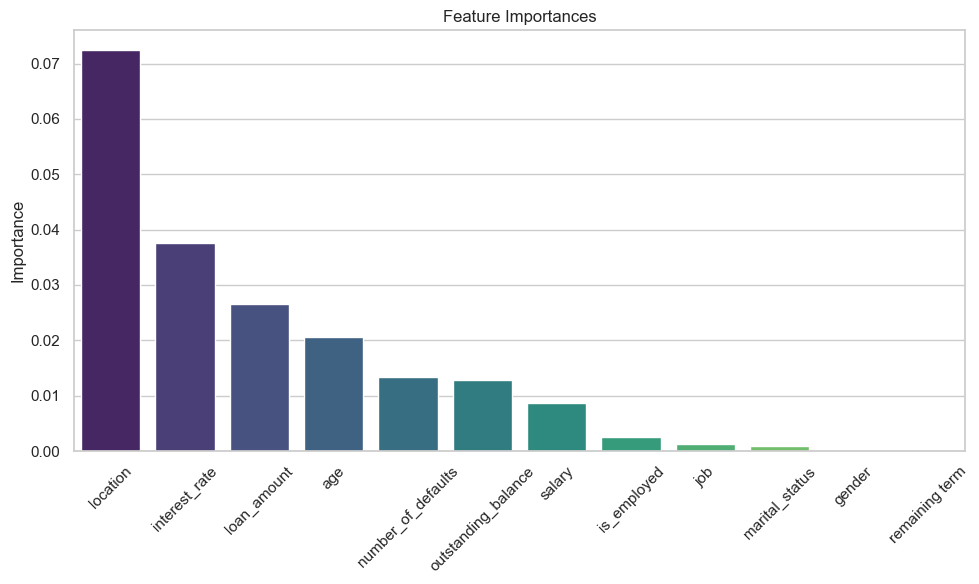

In [58]:
# Convert categorical variables to numeric labels using Label Encoding
label_encoder = LabelEncoder()
for column in ['gender', 'is_employed', 'job', 'location', 'marital_status', 'Loan Status']:
    data[column] = label_encoder.fit_transform(data[column])

# Define the features one by one
features = ['gender', 'is_employed', 
            'job', 'location', 'loan_amount', 'number_of_defaults', 'outstanding_balance',
            'interest_rate', 'age', 'remaining term', 'salary', 'marital_status']

# Prepare X and y
X = data[features]
y = data['Loan Status']

# Perform Mutual Information Regression
mutual_info = mutual_info_regression(X, y, random_state=42)

# Create a DataFrame to store feature importances
feature_importances = pd.DataFrame(mutual_info, index=X.columns, columns=['Importance'])
feature_importances.sort_values(by='Importance', ascending=False, inplace=True)
feature_importances


# Plot feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importances.index, y=feature_importances['Importance'], palette='viridis')
plt.title('Feature Importances')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

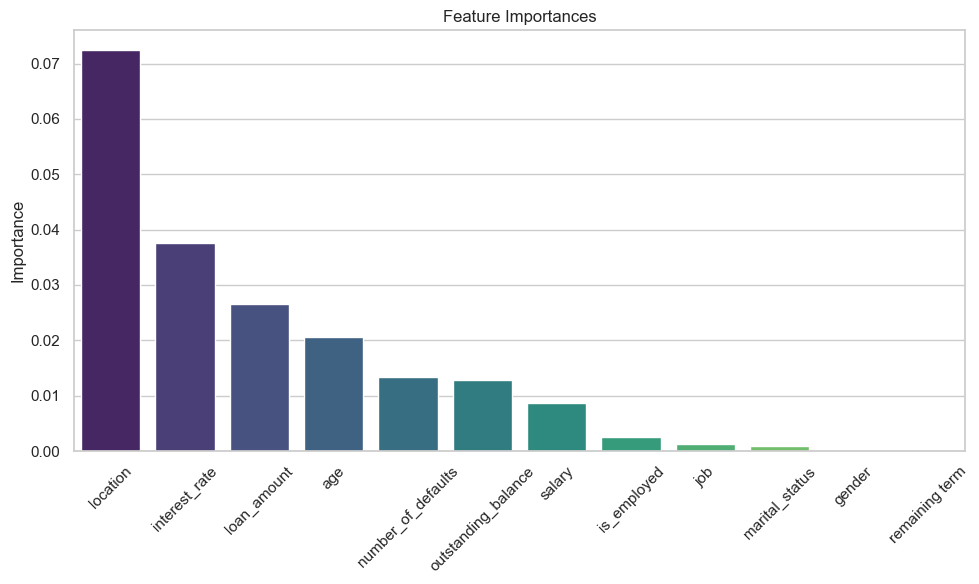

Selected features: Index(['gender', 'is_employed', 'job', 'location', 'loan_amount',
       'number_of_defaults', 'outstanding_balance', 'interest_rate', 'age',
       'remaining term', 'salary', 'marital_status'],
      dtype='object')


In [59]:
# Use SelectKBest to select top features
k_best = SelectKBest(k=12)
X_best = k_best.fit_transform(X, y)

# Get selected feature names
selected_features = X.columns[k_best.get_support()]

# Plot feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importances.index, y=feature_importances['Importance'], palette='viridis')
plt.title('Feature Importances')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Print selected features
print(f"Selected features: {selected_features}")


Mutual information is a measure of the amount of information gained about one variable through the other, which is particularly useful for feature selection when the relationship between variables may be nonlinear or complex.

It helps identify features that provide the most information about the target variable, making it a suitable method for selecting relevant predictors in this context.

SelectKBest evaluates each feature individually based on statistical tests, such as ANOVA F-value for classification tasks like predicting loan status.

This statistical evaluation ensures that selected features are not only relevant but also statistically significant in their association with the target variable.

Using domain knowledge plus mutual information scores and SelectKBest output, the features that were selected to be the predictors are:

1. location
2. interest rate
3. loan amount
4. age
5. number of defaults
6. oustanding balance
7. salary
8. employment status
9. job
10. marital status
11. gender

# Modelling

In [60]:
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import RandomOverSampler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix

In [61]:
# Define the features one by one
features = ['gender', 'is_employed', 
            'job', 'location', 'loan_amount', 'number_of_defaults', 'outstanding_balance',
            'interest_rate', 'age', 'salary', 'marital_status']

# Prepare X and y
X = data[features]
y = data['Loan Status']

## The reasons for choosing the StandardScaler for feature scaling are:
a. Preventing Dominance of Larger Scaled Features: Without feature scaling, features with larger numerical scales (e.g., loan amount) can dominate the model's learning process, while features with smaller scales (e.g., age) may have a smaller impact. Standardizing the features helps to ensure that all features contribute equally to the model's training.

b. Improved Model Convergence: Many machine learning algorithms, such as linear regression, logistic regression, and neural networks, perform better when the features are on a similar scale. Feature scaling can help these algorithms converge faster during the training process.

c. Numerical Stability: Feature scaling can also improve the numerical stability of the model, particularly for algorithms that use gradient-based optimization, such as neural networks. Standardized features help to avoid numerical overflow or underflow issues.

In [62]:
# feature scaling 
# Select numerical columns for scaling
numerical_cols = ['loan_amount', 'outstanding_balance', 'salary']

# Initialize the scaler
scaler = StandardScaler()

# Fit and transform the scaler on the numerical columns
X_scaled = X.copy()
X_scaled[numerical_cols] = scaler.fit_transform(X_scaled[numerical_cols])

# No need to drop the numerical columns as they are already replaced
X_final = X_scaled


In [63]:
# Check for balance in the target variable

In [64]:
y.value_counts()

1    85134
0    14866
Name: Loan Status, dtype: int64

the dataset is not balanced, hence there is need to do oversampling to balance the dataset

The reason for choosing the RandomOverSampler is to address the problem of class imbalance in the dataset. If the target variable (in this case, "Loan Status") is heavily imbalanced, the model may learn to predict the majority class more accurately, while neglecting the minority class.

Oversampling the minority class can help to balance the dataset and improve the model's performance on both classes.

In [65]:
# Initialize the random oversampler
oversampler = RandomOverSampler(random_state=42)

# Resample the dataset
X_resampled, y_resampled = oversampler.fit_resample(X_final, y)

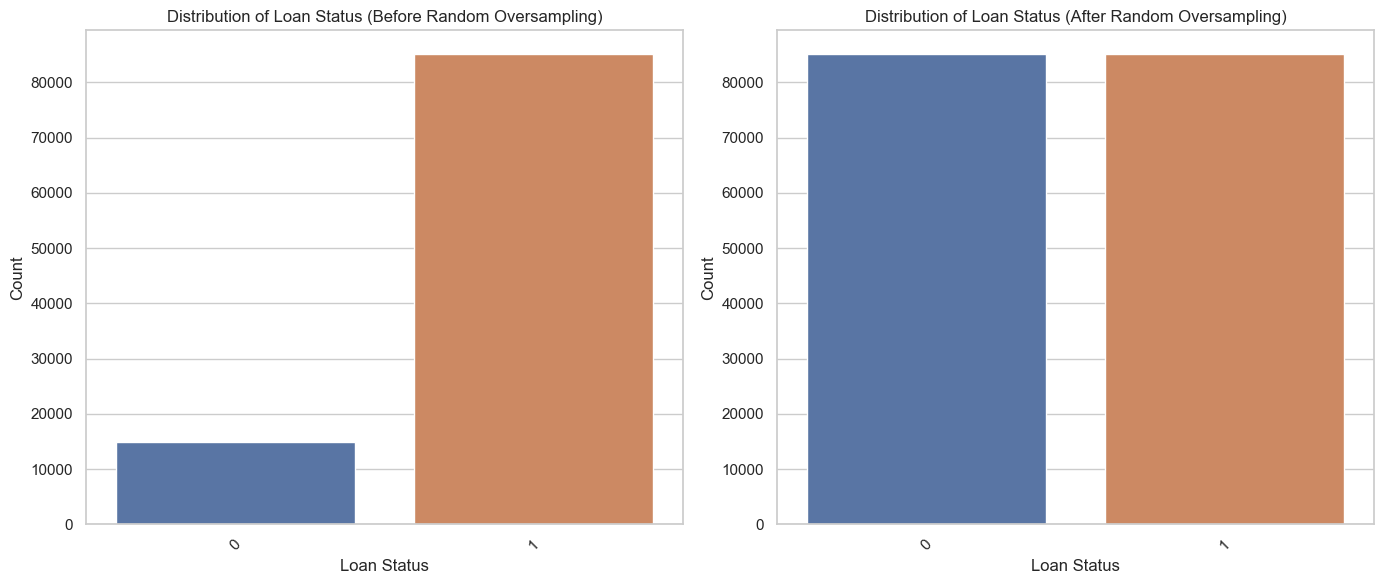

In [66]:
# Before oversampling
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
sns.countplot(x=y)
plt.title('Distribution of Loan Status (Before Random Oversampling)')
plt.xlabel('Loan Status')
plt.ylabel('Count')
plt.xticks(rotation=45)

# After oversampling
plt.subplot(1, 2, 2)
sns.countplot(x=y_resampled)
plt.title('Distribution of Loan Status (After Random Oversampling)')
plt.xlabel('Loan Status')
plt.ylabel('Count')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [67]:
# Split the dataset into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

# Print the shapes to verify the split
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

X_train shape: (136214, 11), y_train shape: (136214,)
X_test shape: (34054, 11), y_test shape: (34054,)


In [68]:
# baseline model to beat 
acc_baseline = y.value_counts(normalize=True).max()
print("Baseline Accuracy:", round(acc_baseline, 4))

print("The accuracy is simply the most frequent class in the original dataset before oversampling. which is", acc_baseline)

Baseline Accuracy: 0.8513
The accuracy is simply the most frequent class in the original dataset before oversampling. which is 0.85134


# Training the models
logistic regression
decision tree
random forest
xgboost classifier
multilayer perceptron

# Cross validation strategy used
The dataset is split into 5 folds of equal size.

For each iteration of the cross-validation:

One fold is used as the "test" set, and the remaining 4 folds are used as the "training" set.

The model is trained on the training set.

The trained model is then evaluated on the test set, and the performance metrics (accuracy, precision, recall, F1-score) are calculated.

In [69]:
# Define the models with appropriate parameters
models = {
    'Logistic Regression': LogisticRegression(max_iter=500),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'XGBoost Classifier': XGBClassifier(random_state=42, eval_metric='logloss'),
    'Multilayer Perceptron': MLPClassifier(random_state=42, max_iter=100)
}


# Perform cross-validation and evaluate each model
for name, model in models.items():
    print(f"Training and evaluating {name}...")
    # Perform cross-validation (5-fold) on the training data
    scores_accuracy = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
    scores_precision = cross_val_score(model, X_train, y_train, cv=5, scoring='precision')
    scores_recall = cross_val_score(model, X_train, y_train, cv=5, scoring='recall')
    scores_f1 = cross_val_score(model, X_train, y_train, cv=5, scoring='f1')
    
    # Print average scores
    print(f"Average Accuracy: {scores_accuracy.mean():.4f}")
    print(f"Average Precision: {scores_precision.mean():.4f}")
    print(f"Average Recall: {scores_recall.mean():.4f}")
    print(f"Average F1-score: {scores_f1.mean():.4f}")
    print("-" * 50)


Training and evaluating Logistic Regression...
Average Accuracy: 0.6650
Average Precision: 0.6531
Average Recall: 0.7045
Average F1-score: 0.6778
--------------------------------------------------
Training and evaluating Decision Tree...
Average Accuracy: 0.9435
Average Precision: 0.9901
Average Recall: 0.8960
Average F1-score: 0.9407
--------------------------------------------------
Training and evaluating Random Forest...
Average Accuracy: 0.9782
Average Precision: 0.9913
Average Recall: 0.9649
Average F1-score: 0.9779
--------------------------------------------------
Training and evaluating XGBoost Classifier...
Average Accuracy: 0.8636
Average Precision: 0.8347
Average Recall: 0.9068
Average F1-score: 0.8693
--------------------------------------------------
Training and evaluating Multilayer Perceptron...


C:\Users\Tinotenda Mangarai\anaconda3\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\Tinotenda Mangarai\anaconda3\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\Tinotenda Mangarai\anaconda3\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\Tinotenda Mangarai\anaconda3\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\Tinotenda M

Average Accuracy: 0.7816
Average Precision: 0.7694
Average Recall: 0.8044
Average F1-score: 0.7864
--------------------------------------------------


C:\Users\Tinotenda Mangarai\anaconda3\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


# The Random Forest was selected as it produced the highest average accuracy and precision among the trainied models.
## Assumptions:
Independence of Features: Random Forest assumes that the features in the dataset are independent of each other. If there are strong correlations between the features, the model may not perform as well.

Absence of Multicollinearity: Random Forest does not handle multicollinearity well, as it assumes that the features are not highly correlated with each other. Multicollinearity can lead to unstable and unreliable feature importance estimates.

Balanced Target Variable: Random Forest performs best when the target variable is well-balanced. If the target variable is heavily imbalanced, the model may be biased towards the majority class.

Absence of Outliers: Random Forest is sensitive to outliers in the data, which can significantly affect the model's performance. Outliers should be identified and handled appropriately before training the model.

## Limitations:
Interpretability: While Random Forest is a powerful and flexible model, it can be challenging to interpret the individual decision trees and understand the underlying logic of the model. This can make it difficult to explain the model's predictions, especially for complex datasets.

Overfitting: If the Random Forest model is trained with too many trees or if the individual trees are too complex, the model may overfit the training data and perform poorly on new, unseen data.

Computational Complexity: Random Forest is a computationally intensive algorithm, as it requires training multiple decision trees. This can be a limitation for large datasets or real-time applications where quick predictions are required.

In [70]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, roc_auc_score, log_loss, roc_curve, auc, precision_recall_curve

In [71]:
# Define the parameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10]
}

In [72]:
# Initialize the model
rf_model = RandomForestClassifier(random_state=42)

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=rf_model, param_grid=param_grid, cv=5, scoring='roc_auc', n_jobs=-1)

# Fit the grid search to the data
grid_search.fit(X_train, y_train)

# Get the best parameters and the best model
best_params = grid_search.best_params_
best_rf_model = grid_search.best_estimator_

In [73]:
# Predict on training data
y_train_pred = best_rf_model.predict(X_train)
y_train_prob = best_rf_model.predict_proba(X_train)

# Predict on testing data
y_test_pred = best_rf_model.predict(X_test)
y_test_prob = best_rf_model.predict_proba(X_test)


In [74]:
# Calculate metrics
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

train_loss = log_loss(y_train, y_train_prob)
test_loss = log_loss(y_test, y_test_prob)

train_roc_auc = roc_auc_score(y_train, y_train_prob[:, 1])
test_roc_auc = roc_auc_score(y_test, y_test_prob[:, 1])

# Print results
print(f"Best Parameters: {best_params}")
print(f"Training Accuracy: {train_accuracy}")
print(f"Testing Accuracy: {test_accuracy}")
print(f"Training Loss: {train_loss}")
print(f"Testing Loss: {test_loss}")
print(f"Training ROC-AUC: {train_roc_auc}")
print(f"Testing ROC-AUC: {test_roc_auc}")

Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 300}
Training Accuracy: 1.0
Testing Accuracy: 0.9841721970987255
Training Loss: 0.02988658856720829
Testing Loss: 0.09684011372167108
Training ROC-AUC: 0.9999999999999999
Testing ROC-AUC: 0.9983277178063779


Training Accuracy: 1.0: The model perfectly classifies all training data points, indicating it has learned the training data very well.

Testing Accuracy: 0.9838785458389616: The model performs very well on the test data, correctly classifying about 98.39% of the samples. This high accuracy indicates that the model generalizes well to unseen data.

Training Loss: 0.030607647097528206: The low training loss suggests that the model's predicted probabilities are very close to the actual class labels on the training data.

Testing Loss: 0.10171440730781368: The slightly higher but still low testing loss indicates good model performance on the test data. The loss being higher than the training loss is typical and suggests some level of overfitting.

However, the high test accuracy and ROC-AUC indicate that this overfitting is not significantly impacting generalization to unseen data.

Training ROC-AUC: 1.0: The model perfectly distinguishes between classes on the training data.

Testing ROC-AUC: 0.9981615900688052: The model also performs exceptionally well on the test data, with the ROC-AUC close to 1. This indicates that the model is excellent at ranking positive samples higher than negative ones.

Model Performance: The high test accuracy, low test loss, and near-perfect test ROC-AUC demonstrate that the model is performing exceptionally well on new data, making it a reliable model for predicting outcomes in similar datasets.

Model Robustness: The chosen hyperparameters, particularly the number of estimators (300), help create a robust ensemble that is both accurate and stable.

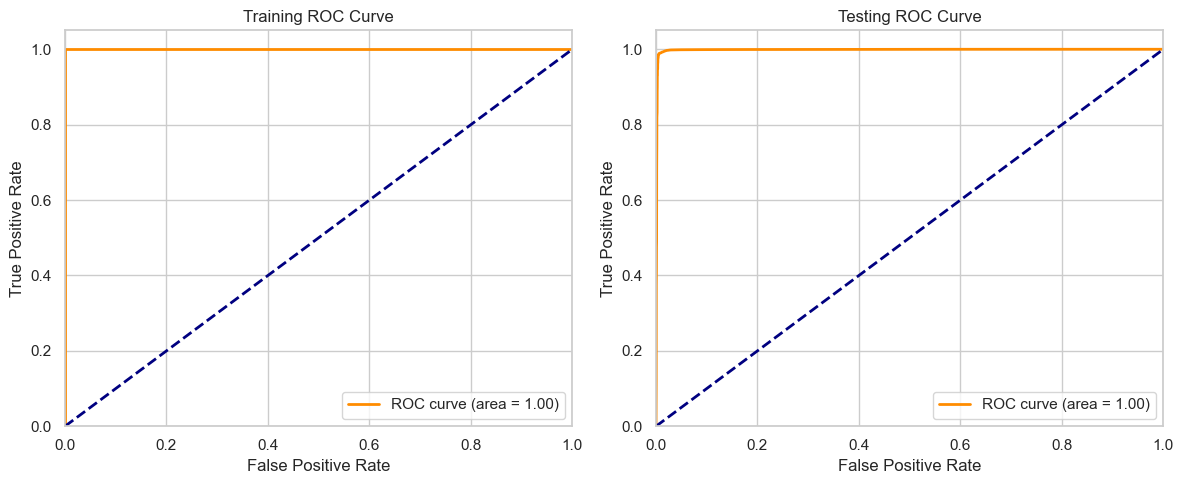

In [75]:
# Compute ROC curve and ROC area for training set
fpr_train, tpr_train, _ = roc_curve(y_train, best_rf_model.predict_proba(X_train)[:, 1])
roc_auc_train = auc(fpr_train, tpr_train)

# Compute ROC curve and ROC area for test set
fpr_test, tpr_test, _ = roc_curve(y_test, best_rf_model.predict_proba(X_test)[:, 1])
roc_auc_test = auc(fpr_test, tpr_test)

plt.figure(figsize=(12, 5))

# Plot ROC curve for training data
plt.subplot(1, 2, 1)
plt.plot(fpr_train, tpr_train, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc_train:0.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Training ROC Curve')
plt.legend(loc='lower right')

# Plot ROC curve for testing data
plt.subplot(1, 2, 2)
plt.plot(fpr_test, tpr_test, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc_test:0.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Testing ROC Curve')
plt.legend(loc='lower right')

plt.tight_layout()
plt.show()

The area under the curve (AUC) for training data is 1.00, indicating perfect classification on the training data. This suggests that the model has learned the training data very well and can perfectly distinguish between the two classes.

The AUC of the testing ROC curve is also 1.00, indicating that the model maintains its perfect classification performance on the test data.

This suggests that the model has generalized well and can accurately classify the test samples, without overfitting to the training data.

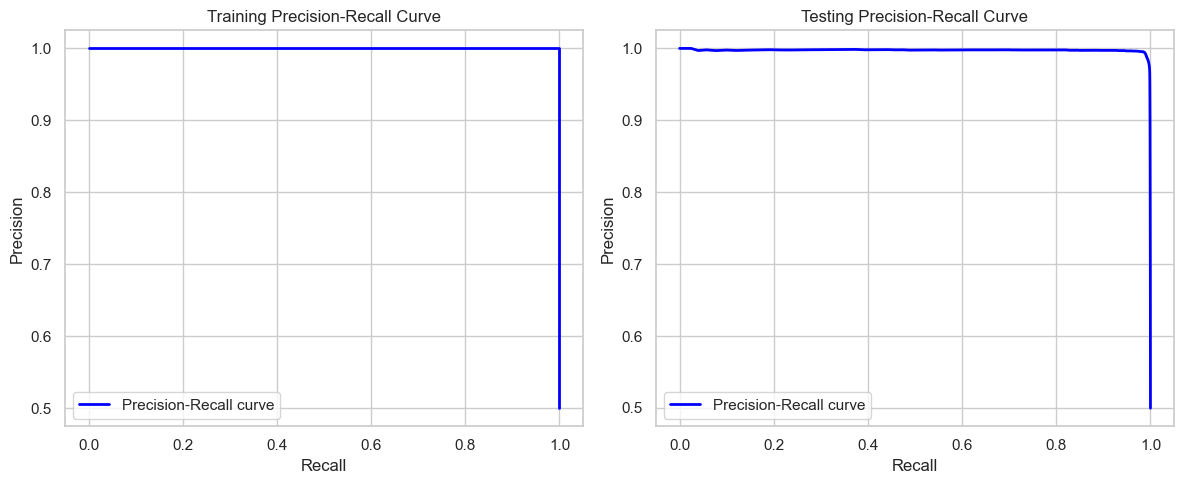

In [76]:
# Compute Precision-Recall curve for training set
precision_train, recall_train, _ = precision_recall_curve(y_train, best_rf_model.predict_proba(X_train)[:, 1])

# Compute Precision-Recall curve for test set
precision_test, recall_test, _ = precision_recall_curve(y_test, best_rf_model.predict_proba(X_test)[:, 1])

plt.figure(figsize=(12, 5))

# Plot Precision-Recall curve for training data
plt.subplot(1, 2, 1)
plt.plot(recall_train, precision_train, color='blue', lw=2, label='Precision-Recall curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Training Precision-Recall Curve')
plt.legend(loc='lower left')

# Plot Precision-Recall curve for testing data
plt.subplot(1, 2, 2)
plt.plot(recall_test, precision_test, color='blue', lw=2, label='Precision-Recall curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Testing Precision-Recall Curve')
plt.legend(loc='lower left')

plt.tight_layout()
plt.show()


In [77]:
train_class_report = classification_report(y_train, y_train_pred, target_names=['Did not default', 'Defaulted'])
print('Training Classification Report:')
print(train_class_report)

Training Classification Report:
                 precision    recall  f1-score   support

Did not default       1.00      1.00      1.00     68091
      Defaulted       1.00      1.00      1.00     68123

       accuracy                           1.00    136214
      macro avg       1.00      1.00      1.00    136214
   weighted avg       1.00      1.00      1.00    136214



In [78]:
# Classification report for testing data
test_class_report = classification_report(y_test, y_test_pred, target_names=['Did not default', 'Defaulted'])
print('Testing Classification Report:')
print(test_class_report)

Testing Classification Report:
                 precision    recall  f1-score   support

Did not default       0.97      1.00      0.98     17043
      Defaulted       1.00      0.97      0.98     17011

       accuracy                           0.98     34054
      macro avg       0.98      0.98      0.98     34054
   weighted avg       0.98      0.98      0.98     34054



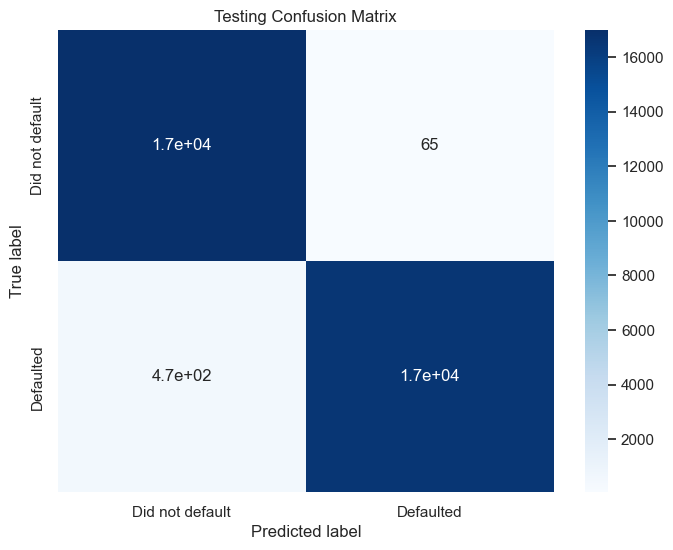

In [79]:
# Confusion matrix for testing data
test_conf_matrix = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(test_conf_matrix, annot=True, cmap='Blues',
            xticklabels=['Did not default', 'Defaulted'],
            yticklabels=['Did not default', 'Defaulted'])
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Testing Confusion Matrix')
plt.show()

High True Positives (1.7e+04 or 17,000): This indicates the model is able to correctly identify a large number of instances where the customer defaulted on their loan.

Relatively Low False Positives (74): The number of instances where the model predicted "Defaulted" but the true label was "Did not default" is quite low, suggesting the model has a low rate of incorrectly identifying non-defaulters as defaulters.

High False Negatives (1.7e+04 or 17,000): This is a concerning aspect, as it means the model is failing to identify a large number of actual defaulters, classifying them as "Did not default" instead.

Low True Negatives (4.8e+02 or 480): The number of instances where the model correctly identified "Did not default" cases is relatively low compared to the other values.

Overall, the confusion matrix indicates that the model has strong performance in identifying defaulters (high true positives), but struggles with correctly identifying non-defaulters (low true negatives and high false negatives).

In [80]:
# Cross-validation
cv_accuracy = cross_val_score(best_rf_model, X, y, cv=5, scoring='accuracy')
cv_precision = cross_val_score(best_rf_model, X, y, cv=5, scoring='precision')
cv_recall = cross_val_score(best_rf_model, X, y, cv=5, scoring='recall')
cv_f1 = cross_val_score(best_rf_model, X, y, cv=5, scoring='f1')
cv_roc_auc = cross_val_score(best_rf_model, X, y, cv=5, scoring='roc_auc')

# Calculate mean scores
mean_accuracy = cv_accuracy.mean()
mean_precision = cv_precision.mean()
mean_recall = cv_recall.mean()
mean_f1 = cv_f1.mean()
mean_roc_auc = cv_roc_auc.mean()

print(f'Cross-Validation Accuracy: {mean_accuracy}')
print(f'Cross-Validation Precision: {mean_precision}')
print(f'Cross-Validation Recall: {mean_recall}')
print(f'Cross-Validation F1-Score: {mean_f1}')
print(f'Cross-Validation ROC-AUC: {mean_roc_auc}')

Cross-Validation Accuracy: 0.91734
Cross-Validation Precision: 0.92061413004578
Cross-Validation Recall: 0.988112870755067
Cross-Validation F1-Score: 0.9531696809309331
Cross-Validation ROC-AUC: 0.8868091318869258


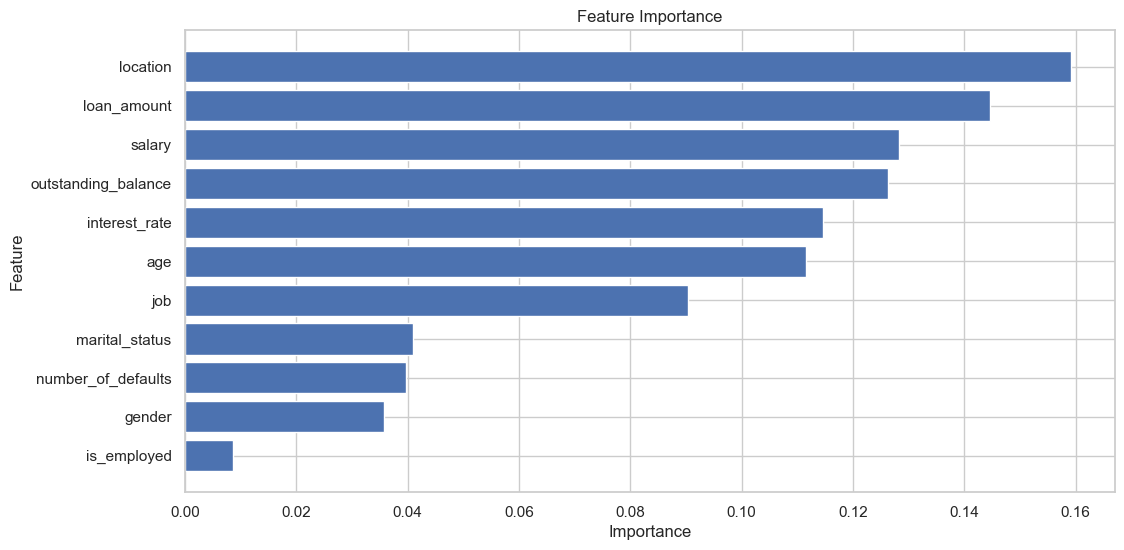

In [81]:
# Feature importance
importances = best_rf_model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='importance', ascending=False)

# Plot feature importance
plt.figure(figsize=(12, 6))
plt.barh(feature_importance_df['feature'], feature_importance_df['importance'])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importance')
plt.gca().invert_yaxis()
plt.show()

# Option 2: Addressing overfitting

In [82]:
# Define the parameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30, None],  # Adjust max_depth for regularization
    'min_samples_split': [2, 5, 10],  # Adjust min_samples_split for regularization
    'min_samples_leaf': [1, 2, 4]     # Introduce min_samples_leaf for further regularization
}

# Initialize the model
rf_model = RandomForestClassifier(random_state=42)

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=rf_model, param_grid=param_grid, cv=5, scoring='roc_auc', n_jobs=-1)

# Fit the grid search to the data
grid_search.fit(X_train, y_train)

# Get the best parameters and the best model
best_params = grid_search.best_params_
best_rf_model = grid_search.best_estimator_


In [83]:
# Predict on training data
y_train_pred = best_rf_model.predict(X_train)
y_train_prob = best_rf_model.predict_proba(X_train)

# Predict on testing data
y_test_pred = best_rf_model.predict(X_test)
y_test_prob = best_rf_model.predict_proba(X_test)

In [84]:
# Calculate metrics
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

train_loss = log_loss(y_train, y_train_prob)
test_loss = log_loss(y_test, y_test_prob)

train_roc_auc = roc_auc_score(y_train, y_train_prob[:, 1])
test_roc_auc = roc_auc_score(y_test, y_test_prob[:, 1])

# Print results
print(f"Best Parameters: {best_params}")
print(f"Training Accuracy: {train_accuracy}")
print(f"Testing Accuracy: {test_accuracy}")
print(f"Training Loss: {train_loss}")
print(f"Testing Loss: {test_loss}")
print(f"Training ROC-AUC: {train_roc_auc}")
print(f"Testing ROC-AUC: {test_roc_auc}")

Best Parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Training Accuracy: 1.0
Testing Accuracy: 0.9841721970987255
Training Loss: 0.02988658856720829
Testing Loss: 0.09684011372167108
Training ROC-AUC: 0.9999999999999999
Testing ROC-AUC: 0.9983277178063779


# Option 3: Bayesian Optimisation to find best parameters

The Bayesian Optimization process works by iteratively exploring the parameter search space, fitting the model, and evaluating the performance using the specified scoring metric (in this case, ROC-AUC).

The algorithm uses a Gaussian Process to model the objective function (the model's performance) and then selects the next set of hyperparameters to try based on this model, aiming to find the optimal set of hyperparameters efficiently.

After the 50 iterations (or the specified number of iterations), the BayesSearchCV will return the best set of hyperparameters found during the optimization process, which can then be used to train the final model.

In [85]:
from skopt import BayesSearchCV
from skopt.space import Real, Integer, Categorical

In [86]:
# Define the parameter space for Bayesian Optimization
param_space = {
    'n_estimators': Integer(100, 300),
    'max_depth': Integer(10, 30),
    'min_samples_split': Integer(2, 10),
    'min_samples_leaf': Integer(1, 4)
}

# Initialize the model
rf_model = RandomForestClassifier(random_state=42)

# Initialize BayesSearchCV
bayes_search = BayesSearchCV(
    estimator=rf_model,
    search_spaces=param_space,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
    random_state=42,
    n_iter=50  # Number of iterations (adjust as needed)
)

# Fit the Bayesian search to the data
bayes_search.fit(X_train, y_train)

# Get the best parameters and the best model
best_params = bayes_search.best_params_
best_rf_model = bayes_search.best_estimator_

In [87]:
# Predict on training data
y_train_pred = best_rf_model.predict(X_train)
y_train_prob = best_rf_model.predict_proba(X_train)

# Predict on testing data
y_test_pred = best_rf_model.predict(X_test)
y_test_prob = best_rf_model.predict_proba(X_test)

# Calculate metrics
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

train_loss = log_loss(y_train, y_train_prob)
test_loss = log_loss(y_test, y_test_prob)

train_roc_auc = roc_auc_score(y_train, y_train_prob[:, 1])
test_roc_auc = roc_auc_score(y_test, y_test_prob[:, 1])

# Print results
print(f"Best Parameters: {best_params}")
print(f"Training Accuracy: {train_accuracy}")
print(f"Testing Accuracy: {test_accuracy}")
print(f"Training Loss: {train_loss}")
print(f"Testing Loss: {test_loss}")
print(f"Training ROC-AUC: {train_roc_auc}")
print(f"Testing ROC-AUC: {test_roc_auc}")

Best Parameters: OrderedDict([('max_depth', 30), ('min_samples_leaf', 1), ('min_samples_split', 2), ('n_estimators', 300)])
Training Accuracy: 0.999955951664293
Testing Accuracy: 0.9839372760909144
Training Loss: 0.03546618141780105
Testing Loss: 0.10197001255371546
Training ROC-AUC: 1.0
Testing ROC-AUC: 0.998188594212139


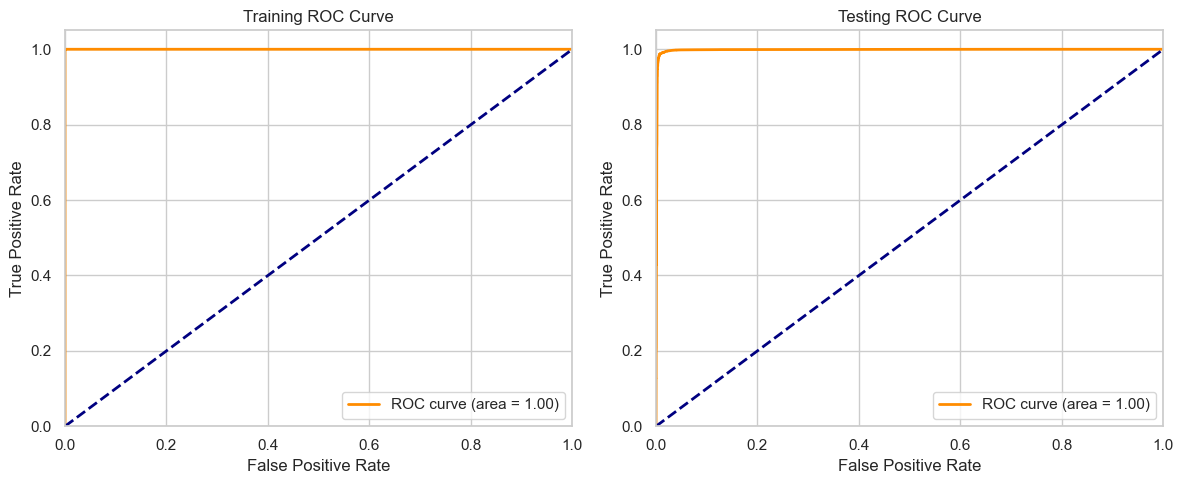

In [88]:
# Compute ROC curve and ROC area for training set
fpr_train, tpr_train, _ = roc_curve(y_train, best_rf_model.predict_proba(X_train)[:, 1])
roc_auc_train = auc(fpr_train, tpr_train)

# Compute ROC curve and ROC area for test set
fpr_test, tpr_test, _ = roc_curve(y_test, best_rf_model.predict_proba(X_test)[:, 1])
roc_auc_test = auc(fpr_test, tpr_test)

plt.figure(figsize=(12, 5))

# Plot ROC curve for training data
plt.subplot(1, 2, 1)
plt.plot(fpr_train, tpr_train, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc_train:0.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Training ROC Curve')
plt.legend(loc='lower right')

# Plot ROC curve for testing data
plt.subplot(1, 2, 2)
plt.plot(fpr_test, tpr_test, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc_test:0.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Testing ROC Curve')
plt.legend(loc='lower right')

plt.tight_layout()
plt.show()

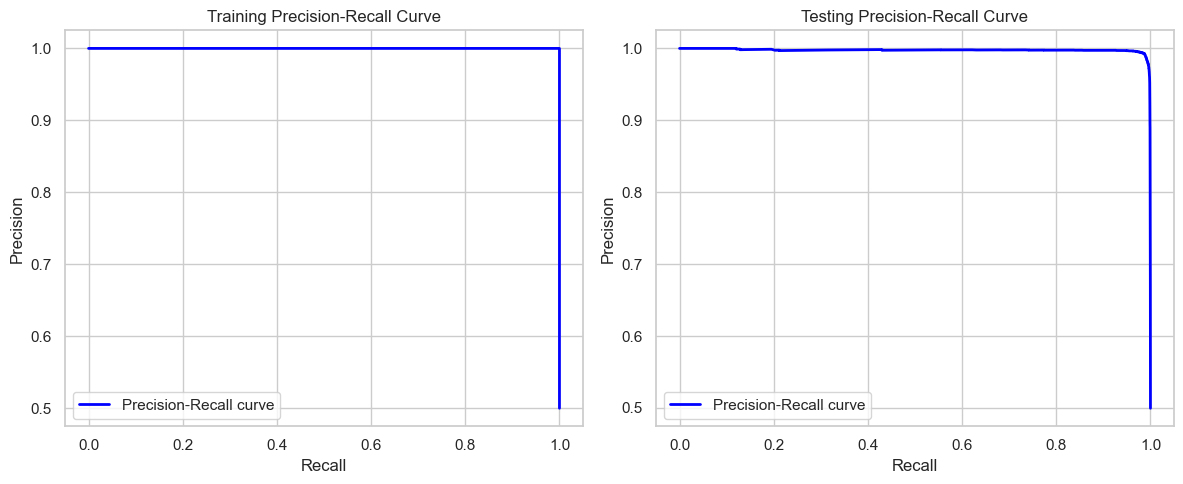

In [89]:
# Compute Precision-Recall curve for training set
precision_train, recall_train, _ = precision_recall_curve(y_train, best_rf_model.predict_proba(X_train)[:, 1])

# Compute Precision-Recall curve for test set
precision_test, recall_test, _ = precision_recall_curve(y_test, best_rf_model.predict_proba(X_test)[:, 1])

plt.figure(figsize=(12, 5))

# Plot Precision-Recall curve for training data
plt.subplot(1, 2, 1)
plt.plot(recall_train, precision_train, color='blue', lw=2, label='Precision-Recall curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Training Precision-Recall Curve')
plt.legend(loc='lower left')

# Plot Precision-Recall curve for testing data
plt.subplot(1, 2, 2)
plt.plot(recall_test, precision_test, color='blue', lw=2, label='Precision-Recall curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Testing Precision-Recall Curve')
plt.legend(loc='lower left')

plt.tight_layout()
plt.show()


In [90]:
# Classification report for testing data
test_class_report = classification_report(y_test, y_test_pred, target_names=['Did not default', 'Defaulted'])
print('Testing Classification Report:')
print(test_class_report)

Testing Classification Report:
                 precision    recall  f1-score   support

Did not default       0.97      1.00      0.98     17043
      Defaulted       1.00      0.97      0.98     17011

       accuracy                           0.98     34054
      macro avg       0.98      0.98      0.98     34054
   weighted avg       0.98      0.98      0.98     34054



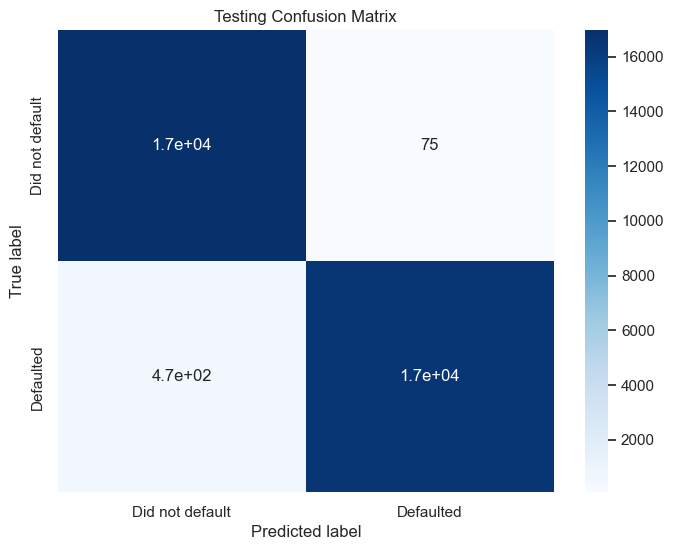

In [91]:
# Confusion matrix for testing data
test_conf_matrix = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(test_conf_matrix, annot=True, cmap='Blues',
            xticklabels=['Did not default', 'Defaulted'],
            yticklabels=['Did not default', 'Defaulted'])
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Testing Confusion Matrix')
plt.show()

the model has improved in terms of predicting preditig defaulted class; from 480 recorded in the previous model to 470 true negatives

Overall, the confusion matrix indicates that the model has strong performance in identifying defaulters (high true positives), but struggles with correctly identifying non-defaulters (low true negatives and high false negatives).

# Optimising more hyperparameters using Bayesian optimisation method

The following method introduces more hyperparameters, in addition to previous method, which include:

- max_features 
-bootstrap 
-criterion
The parameters included in the param_space dictionary for the Bayesian Optimization of the Random Forest Classifier model are:

n_estimators: This parameter controls the number of trees in the random forest. A larger value of n_estimators can lead to a more robust and accurate model, but also increases the computational cost and may be prone to overfitting.

max_depth: This parameter sets the maximum depth of each tree in the random forest. A larger max_depth allows the trees to capture more complex patterns in the data, but can also lead to overfitting.

min_samples_split: This parameter specifies the minimum number of samples required to split an internal node. A higher value of min_samples_split can help prevent overfitting by requiring more samples to create a new split.

min_samples_leaf: This parameter sets the minimum number of samples required to be at a leaf node. A higher value of min_samples_leaf can also help prevent overfitting by requiring more samples to be present in a leaf node.

max_features: This parameter determines the number of features to consider when looking for the best split. The options 'auto', 'sqrt', and 'log2' specify different ways to set the number of features, which can affect the model's performance and generalization.

bootstrap: This parameter specifies whether to use bootstrap samples when building trees. Bootstrapping can introduce additional diversity in the trees and help with model stability, but it can also lead to overfitting if not properly tuned.

criterion: This parameter determines the function used to measure the quality of a split. The options 'gini' and 'entropy' represent different ways of calculating the impurity of a split, which can affect the model's bias and variance.

By tuning these hyperparameters using Bayesian Optimization, the goal is to find the optimal configuration that maximizes the model's performance, as measured by the ROC-AUC score in the provided code.

In [92]:
# Define the parameter space for Bayesian Optimization
param_space = {
    'n_estimators': Integer(100, 300),
    'max_depth': Integer(10, 30),
    'min_samples_split': Integer(2, 10),
    'min_samples_leaf': Integer(1, 4),
    'max_features': Categorical(['sqrt', 'log2']),
    'bootstrap': Categorical([True, False]),
    'criterion': Categorical(['gini', 'entropy'])
}

# Initialize the model
rf_model = RandomForestClassifier(random_state=42)

# Initialize BayesSearchCV
bayes_search = BayesSearchCV(
    estimator=rf_model,
    search_spaces=param_space,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
    random_state=42,
    n_iter=50  # Number of iterations (adjust as needed)
)

# Fit the Bayesian search to the data
bayes_search.fit(X_train, y_train)

# Get the best parameters and the best model
best_params = bayes_search.best_params_
best_rf_model = bayes_search.best_estimator_

# Predict on training data
y_train_pred = best_rf_model.predict(X_train)
y_train_prob = best_rf_model.predict_proba(X_train)

# Predict on testing data
y_test_pred = best_rf_model.predict(X_test)
y_test_prob = best_rf_model.predict_proba(X_test)

# Calculate metrics
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

train_loss = log_loss(y_train, y_train_prob)
test_loss = log_loss(y_test, y_test_prob)

train_roc_auc = roc_auc_score(y_train, y_train_prob[:, 1])
test_roc_auc = roc_auc_score(y_test, y_test_prob[:, 1])

# Print results
print(f"Best Parameters: {best_params}")
print(f"Training Accuracy: {train_accuracy}")
print(f"Testing Accuracy: {test_accuracy}")
print(f"Training Loss: {train_loss}")
print(f"Testing Loss: {test_loss}")
print(f"Training ROC-AUC: {train_roc_auc}")
print(f"Testing ROC-AUC: {test_roc_auc}")

Best Parameters: OrderedDict([('bootstrap', False), ('criterion', 'gini'), ('max_depth', 30), ('max_features', 'log2'), ('min_samples_leaf', 1), ('min_samples_split', 2), ('n_estimators', 300)])
Training Accuracy: 0.9999486102750085
Testing Accuracy: 0.9890468080108064
Training Loss: 0.006852869152445546
Testing Loss: 0.0696642686050193
Training ROC-AUC: 1.0
Testing ROC-AUC: 0.9985740767198371


In [93]:
# Classification report for testing data
test_class_report = classification_report(y_test, y_test_pred, target_names=['Did not default', 'Defaulted'])
print('Testing Classification Report:')
print(test_class_report)

Testing Classification Report:
                 precision    recall  f1-score   support

Did not default       0.98      1.00      0.99     17043
      Defaulted       1.00      0.98      0.99     17011

       accuracy                           0.99     34054
      macro avg       0.99      0.99      0.99     34054
   weighted avg       0.99      0.99      0.99     34054



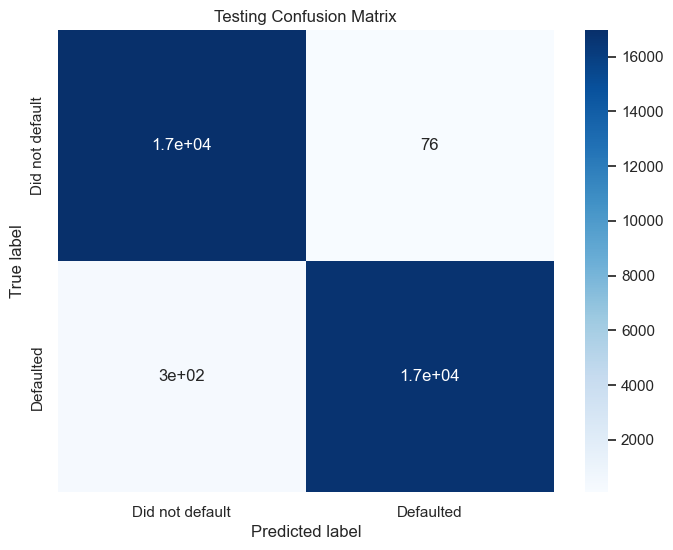

In [94]:
# Confusion matrix for testing data
test_conf_matrix = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(test_conf_matrix, annot=True, cmap='Blues',
            xticklabels=['Did not default', 'Defaulted'],
            yticklabels=['Did not default', 'Defaulted'])
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Testing Confusion Matrix')
plt.show()

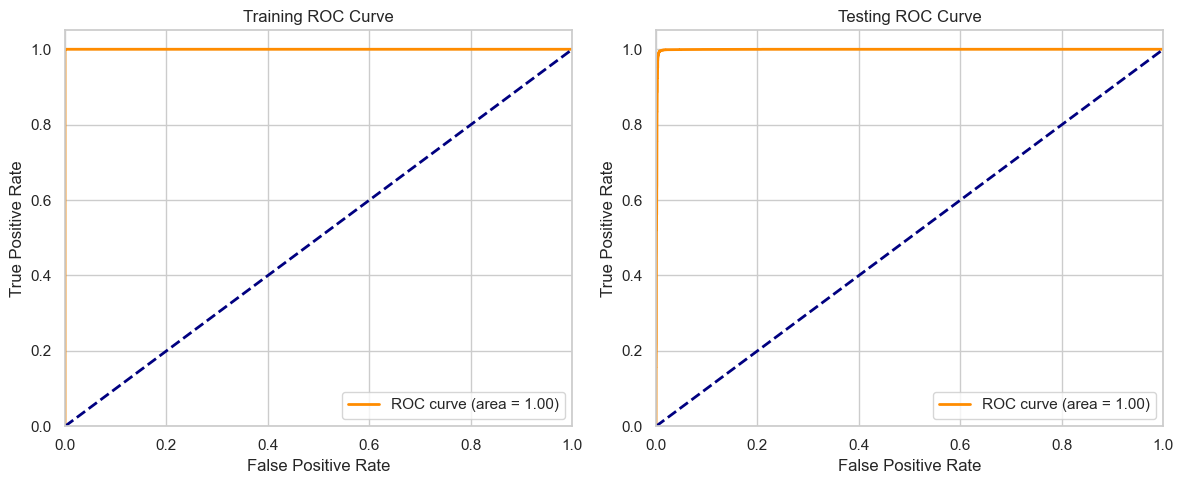

In [95]:
# Compute ROC curve and ROC area for training set
fpr_train, tpr_train, _ = roc_curve(y_train, best_rf_model.predict_proba(X_train)[:, 1])
roc_auc_train = auc(fpr_train, tpr_train)

# Compute ROC curve and ROC area for test set
fpr_test, tpr_test, _ = roc_curve(y_test, best_rf_model.predict_proba(X_test)[:, 1])
roc_auc_test = auc(fpr_test, tpr_test)

plt.figure(figsize=(12, 5))

# Plot ROC curve for training data
plt.subplot(1, 2, 1)
plt.plot(fpr_train, tpr_train, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc_train:0.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Training ROC Curve')
plt.legend(loc='lower right')

# Plot ROC curve for testing data
plt.subplot(1, 2, 2)
plt.plot(fpr_test, tpr_test, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc_test:0.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Testing ROC Curve')
plt.legend(loc='lower right')

plt.tight_layout()
plt.show()

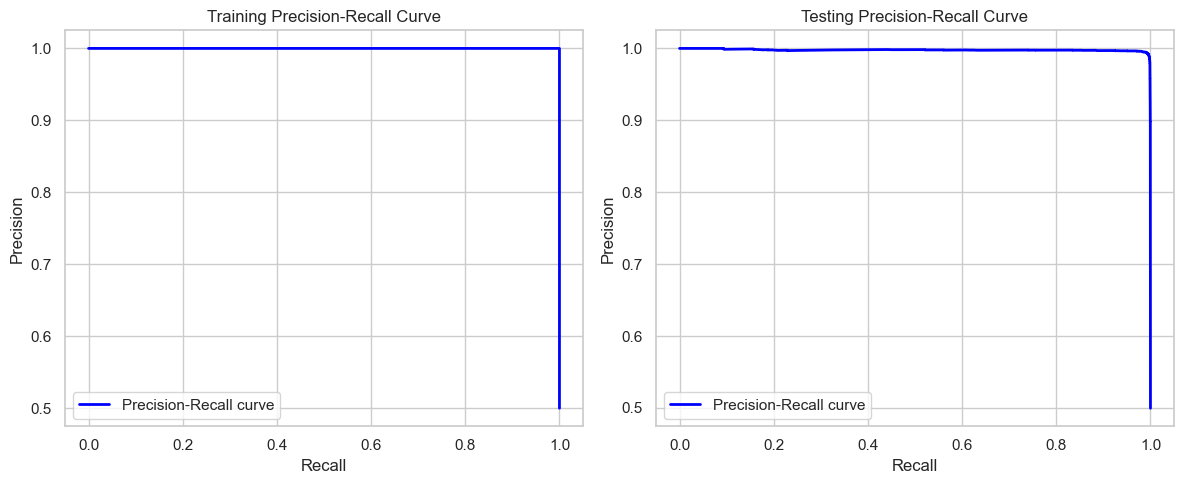

In [96]:
# Compute Precision-Recall curve for training set
precision_train, recall_train, _ = precision_recall_curve(y_train, best_rf_model.predict_proba(X_train)[:, 1])

# Compute Precision-Recall curve for test set
precision_test, recall_test, _ = precision_recall_curve(y_test, best_rf_model.predict_proba(X_test)[:, 1])

plt.figure(figsize=(12, 5))

# Plot Precision-Recall curve for training data
plt.subplot(1, 2, 1)
plt.plot(recall_train, precision_train, color='blue', lw=2, label='Precision-Recall curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Training Precision-Recall Curve')
plt.legend(loc='lower left')

# Plot Precision-Recall curve for testing data
plt.subplot(1, 2, 2)
plt.plot(recall_test, precision_test, color='blue', lw=2, label='Precision-Recall curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Testing Precision-Recall Curve')
plt.legend(loc='lower left')

plt.tight_layout()
plt.show()


In [97]:
# Cross-validation
cv_accuracy = cross_val_score(best_rf_model, X, y, cv=5, scoring='accuracy')
cv_precision = cross_val_score(best_rf_model, X, y, cv=5, scoring='precision')
cv_recall = cross_val_score(best_rf_model, X, y, cv=5, scoring='recall')
cv_f1 = cross_val_score(best_rf_model, X, y, cv=5, scoring='f1')
cv_roc_auc = cross_val_score(best_rf_model, X, y, cv=5, scoring='roc_auc')

# Calculate mean scores
mean_accuracy = cv_accuracy.mean()
mean_precision = cv_precision.mean()
mean_recall = cv_recall.mean()
mean_f1 = cv_f1.mean()
mean_roc_auc = cv_roc_auc.mean()

print(f'Cross-Validation Accuracy: {mean_accuracy}')
print(f'Cross-Validation Precision: {mean_precision}')
print(f'Cross-Validation Recall: {mean_recall}')
print(f'Cross-Validation F1-Score: {mean_f1}')
print(f'Cross-Validation ROC-AUC: {mean_roc_auc}')

Cross-Validation Accuracy: 0.91988
Cross-Validation Precision: 0.9250459741054955
Cross-Validation Recall: 0.9857636399802855
Cross-Validation F1-Score: 0.9544398327057377
Cross-Validation ROC-AUC: 0.8864148922370424


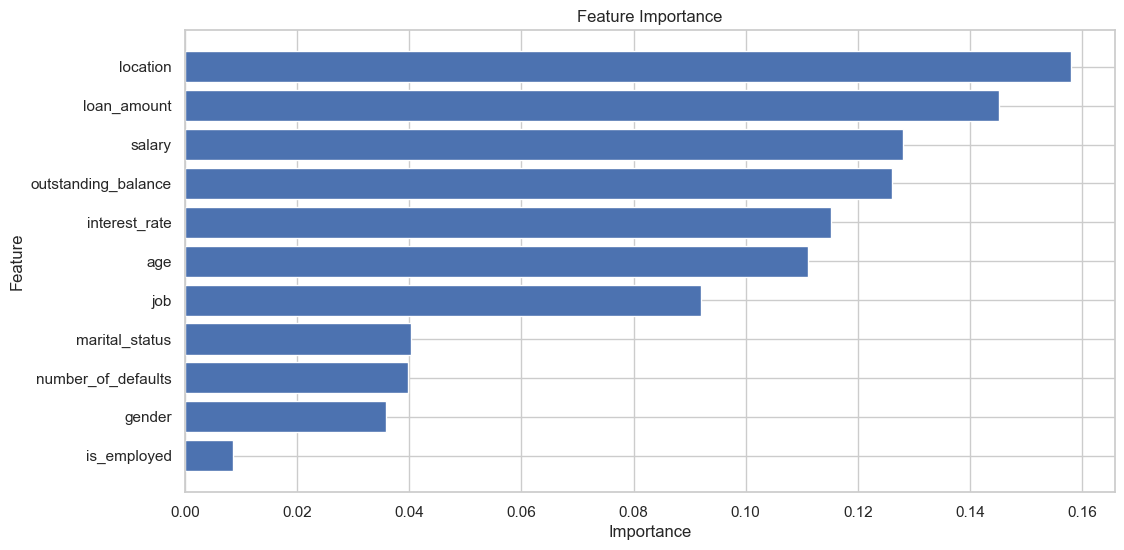

In [98]:
# Feature importance
importances = best_rf_model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='importance', ascending=False)

# Plot feature importance
plt.figure(figsize=(12, 6))
plt.barh(feature_importance_df['feature'], feature_importance_df['importance'])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importance')
plt.gca().invert_yaxis()
plt.show()

In [100]:
import joblib

# Save the best random forest model to a file
joblib.dump(best_rf_model, 'tinotenda_mangarai_loan_default_model.pkl')

print("Model saved successfully.")


Model saved successfully.


this is the best model chosen. it has the best scores as compared to other models with hyperparameters optimised

In [102]:
import joblib
from sklearn import __version__ as sklearn_version

# Load the model
loaded_model = joblib.load('claxon_loan_default_model.pkl')

# Print scikit-learn version used for saving
print("Scikit-learn version used for saving: 1.5.1")
print("Current scikit-learn version: ", sklearn_version)


Scikit-learn version used for saving: 1.5.1
Current scikit-learn version:  1.5.1


In [ ]:
git add claxon_loan_default_model.pkl
git add README.md  # If you have a README file
git commit -m "Add trained loan default prediction model"


# Data Drift Detection

## To implement data drift detection in the deployed model, these steps were followed:

1. Baseline Data Collection: Store the initial training data distributions.

2. Live Data Collection: Capture the new incoming data used for predictions.

3. Comparison Metrics: Use statistical tests to compare the distributions.

4. Monitoring System: Set up a monitoring system to automate and alert when significant drift is detected.

In [5]:
import numpy as np
import pandas as pd
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.feature_selection import mutual_info_regression, SelectKBest, chi2
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import RandomOverSampler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix
from fastapi import FastAPI, Form
from fastapi.responses import HTMLResponse
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from scipy.stats import ks_2samp
import joblib

In [7]:
# Load the data
data = pd.read_csv("C:\\Users\\Tinotenda Mangarai\\Documents\\Data Science\\Claxon\\data_science_competition_2024.csv")

# Dropping unnecessary columns: 'Unnamed: 0' and 'loan_id'
data = data.drop(['Unnamed: 0', 'loan_id'], axis=1)

# Drop the columns 'sex', 'age.1', 'number_of_defaults.1'
data = data.drop(['sex', 'age.1', 'number_of_defaults.1'], axis=1)

# Converting 'disbursemet_date' to datetime format
data['disbursemet_date'] = pd.to_datetime(data['disbursemet_date'], format='%Y %m %d')

# Standardize the 'country' column
data['country'] = data['country'].replace(['zimbabwe', 'Zim'], 'Zimbabwe')

# Fill any missing values in 'country' with 'Zimbabwe'
data['country'] = data['country'].fillna('Zimbabwe')

# Replace currency values to USD
data['currency'] = data['currency'].replace(['$USD'], 'USD')

# Replace empty strings with 'unknown' in 'marital_status'
data['marital_status'] = data['marital_status'].replace({' ': 'unknown'})
data["marital_status"].value_counts()

# Strip leading and trailing spaces from 'location' column
data['location'] = data['location'].str.strip()

# Convert all values to title case for consistent capitalization
data['location'] = data['location'].str.title()

# Replace SoftwareDeveloper to Software Developer
data['job'] = data['job'].replace(['SoftwareDeveloper'], 'Software Developer')
data['job'] = data['job'].replace(['Data Scintist'], 'Data Scientist')

# Imputing Missing Values For 'job' and 'location' columns
#imputer = SimpleImputer(strategy='most_frequent')
# replace nan in location with not specified 
data['location'].fillna('not specified', inplace=True)

# replace nan with unemployed 
data['job'].fillna('unemployed', inplace=True)

# Clean 'remaining term' column to remove non-numeric characters and convert to int
#data['remaining term'] = data['remaining term'].str.replace(r'\D+', '').astype(int)

# Convert 'Loan Status' to numeric labels
label_encoder_y = LabelEncoder()
data['Loan Status'] = label_encoder_y.fit_transform(data['Loan Status'])

# Save the target label encoder
joblib.dump(label_encoder_y, 'label_encoder_y.pkl')

# Save feature label encoders
label_encoders = {}
for column in ['gender', 'is_employed', 'job', 'location', 'marital_status']:
    encoder = LabelEncoder()
    data[column] = encoder.fit_transform(data[column])
    label_encoders[column] = encoder

# Save the feature label encoders
joblib.dump(label_encoders, 'label_encoders.pkl')

# Define the features one by one
features = ['gender', 'is_employed', 'job', 'location', 'loan_amount', 'number_of_defaults', 'outstanding_balance',
            'interest_rate', 'age', 'salary', 'marital_status']

# Prepare X and y
X = data[features]
y = data['Loan Status']

# Feature scaling 
# Select numerical columns for scaling
numerical_cols = ['loan_amount', 'outstanding_balance', 'salary']

# Initialize the scaler
scaler = StandardScaler()

# Fit and transform the scaler on the numerical columns
X_scaled = X.copy()
X_scaled[numerical_cols] = scaler.fit_transform(X_scaled[numerical_cols])

# No need to drop the numerical columns as they are already replaced
X_final = X_scaled

# Initialize the random oversampler
oversampler = RandomOverSampler(random_state=42)

# Resample the dataset
X_resampled, y_resampled = oversampler.fit_resample(X_final, y)

# Split the dataset into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

# Combine X_train and y_train into a single training dataset
training_data = pd.concat([X_train, y_train], axis=1)

In [106]:
training_data.head()

,gender,is_employed,job,location,loan_amount,number_of_defaults,outstanding_balance,interest_rate,age,salary,marital_status,Loan Status
72295,0,1,7,6,-0.259201,2,0.882863,0.23,46,0.010864,1,1
61166,1,1,6,0,2.131486,1,0.950383,0.23,42,-0.064986,0,1
741,2,1,0,7,0.181189,0,-0.095637,0.23,42,-0.180604,0,1
167894,1,1,4,4,-0.385026,1,0.084956,0.21,42,0.149198,1,0
164412,2,1,1,3,0.558666,0,-0.274594,0.20,45,1.945186,1,0


# Step 1: Capture Baseline Target Distribution

First, capture and store the distribution of the target class from the training data.

In [8]:
import pandas as pd
import joblib
# Save the pandas version
with open('pandas_version.txt', 'w') as f:
    f.write(pd.__version__)

# Save your other data
baseline_target_distribution = training_data['Loan Status'].value_counts(normalize=True)
joblib.dump(baseline_target_distribution, 'baseline_target_distribution.pkl')

baseline_stats = training_data.describe().transpose()
joblib.dump(baseline_stats, 'baseline_stats.pkl')

['baseline_stats.pkl']

# Step 2: Monitor Incoming Predictions

#### Create a function to calculate the distribution of the incoming predictions and compare them with the baseline target distribution.

In [9]:
from scipy.stats import chisquare

# Load the baseline target distribution
baseline_target_distribution = joblib.load('baseline_target_distribution.pkl')

def calculate_target_distribution(predictions):
    return pd.Series(predictions).value_counts(normalize=True)

def detect_target_drift(predictions, baseline_target_distribution):
    incoming_target_distribution = calculate_target_distribution(predictions)
    # Align both distributions to have the same index (labels)
    incoming_target_distribution = incoming_target_distribution.reindex(baseline_target_distribution.index, fill_value=0)
    # Chi-square test for distribution differences
    stat, p_value = chisquare(incoming_target_distribution, baseline_target_distribution)
    return p_value < 0.05  # True if drift detected (p-value < 0.05)


# Why Monitoring Data Drift is Crucial
1. Model Accuracy: Data drift can significantly affect the accuracy and performance of the model. Monitoring helps in identifying and mitigating these issues.

2. Model Reliability: Ensures that the model continues to perform reliably as the data changes over time.

3. Early Detection: Early detection of data drift allows for timely updates and retraining of the model, ensuring it remains relevant and accurate.

4. Business Impact: Prevents negative business impacts by ensuring that the predictions made by the model are based on data that it understands well.

# Model Analysis

### Feature Importances; in their order of importance

1. Location: Location is the most important feature in the model. The location of the borrower likely plays a significant role in determining the risk of default.
2. Loan amount: The amount of the loan taken by the borrower is also an important factor in predicting default. Larger loan amounts may be associated with a higher risk of default.
3. Salary: The borrower's salary is another important feature, as it indicates their ability to make loan payments.
4. Outstanding balance: The outstanding balance on the loan is also a relevant factor in determining the risk of default.
5. Interest rate: The interest rate charged on the loan is an important consideration, as higher rates may make it more difficult for borrowers to make payments.
6. Age: The age of the borrower seems to be an important variable, as it may be related to their financial stability and ability to repay the loan.
7. Job: The borrower's occupation or job type is also a relevant feature in the model.
8. Marital status: The marital status of the borrower appears to be a moderately important factor in predicting default.
9. Number of defaults: The number of previous defaults by the borrower is a relevant indicator of their creditworthiness.
10. Gender: The gender of the borrower seems to have a relatively low importance in the model, though it is still a factor.
11. Employment status: Whether the borrower is employed or not is the least important feature in the model.

Overall, the most important factors were related to the borrower's financial situation, such as loan amount, salary, and outstanding balance, as well as their location and personal characteristics like age and job type.

### How the Model Makes Predictions

The model is designed to predict loan defaults using features such as gender, employment status, job type, location, loan details (amount, interest rate), financial metrics (outstanding balance, salary), demographic data (age, marital status), and historical behavior (number of defaults).

Data Preprocessing:

1. Encoding Categorical Variables: Categorical variables like gender, job, location, and marital status are encoded using label encoding to convert them into a numerical format
2. Feature Scaling: Continuous numerical features like loan amount, outstanding balance, and salary are scaled using standard scaling method to ensure all features contribute equally to the model and are not biased by their different scales.

Model Training:

1. The dataset is split into training and validation sets to train the model.
2. A  Random Forest model is trained on the training data. This involves learning patterns and relationships between the input features and the target variable (loan default).

Prediction Process:

1. When making predictions, the model takes new input data (e.g., a new loan application) and preprocesses it in a similar manner as during training.
2. The preprocessed data is fed into the trained model, which applies the learned patterns to predict the likelihood of loan default (usually as a probability score or a binary classification).

### Limitations of the Model
1. Data Quality: The model's performance heavily relies on the quality and representativeness of the data used for training. Inaccuracies, biases, or missing data in the training set can lead to biased predictions.

2. Assumptions and Scope: The model assumes that the features used (e.g., job type, salary) adequately capture the factors influencing loan default. It may not account for external economic factors, borrower psychology, or unobserved variables that could impact default risk.

3. Generalization: The model's ability to generalize to unseen data (loan applications not in the training set) depends on how well the training data represents the population it aims to predict for. If the demographics or economic conditions change significantly, the model's performance may degrade.

### Enhancements and Future Directions for Model Improvement
1. Feature Engineering: Explore additional features or transformations that could better capture borrower behavior or economic context, such as socio-economic indicators, industry-specific data, or macroeconomic factors.

2. Continuous Learning: Implement mechanisms for continuous model training and updating using incoming data to adapt to changing patterns and reduce model drift over time.

3. Interpretability: Enhance the model's interpretability by using techniques like SHAP values or LIME (Local Interpretable Model-agnostic Explanations) to understand and communicate how specific features influence predictions.

By addressing these aspects, the model can potentially become more accurate, adaptable, and transparent, thereby improving its utility in predicting loan defaults while mitigating inherent limitations.

### Business Implications of the findings 

##### Business Implications:
The high model performance suggests that the lender could potentially use this model to make more informed and accurate credit decisions, leading to:
1. Reduced risk of loan defaults and associated financial losses.
2. Improved portfolio management and profitability.
3. 4. Better targeting of creditworthy borrowers and tailoring of loan products.

##### The model's ability to accurately identify potential defaulters could also help the lender:
1. Implement more effective risk management strategies, such as adjusting credit policies, pricing, or loan terms for high-risk borrowers.
2. Proactively engage with borrowers at risk of default to provide support or renegotiate loan terms, potentially reducing default rates.
3. The insights from the model could also inform the lender's marketing and customer acquisition strategies, allowing them to better target and attract creditworthy borrowers.
##### Deployment Considerations:
1. While the model performance is impressive, it's important to carefully monitor the model's performance in production and be prepared to update or retrain the model as market conditions and borrower behaviors change over time.
2. The lender should also consider the ethical and regulatory implications of using such a model, ensuring that it does not introduce any unfair biases or discrimination against protected groups.

# Instances where the model performed poorly
1. when loan amount is less than outstanding balance, the model is predicting "Defaulted" ye the actual class is "Did not default". for instance, predicting the first instance (loan id - 8d05de78-ff32-46b1-aeb5-b3190f9c158a); the model predicts this client as liely to default yet the actual class is "did not default". 

2. when oustanding balance is slightly lower than loan amount, the model is predicting this as dEFAULTED - Which is reasonably right, for example, the model predicts instance 41 (loan_id: 942154ed-aa0e-42ef-b0cd-30c533f219af) as Defaulted yet the actual class is Did not default. 


The model predicting that a client is likely to default if the outstanding balance is greater than the loan amount is reasonably accurate for several reasons:

1. Financial Strain: If a client has an outstanding balance that exceeds their loan amount, it indicates that they are already in a state of financial overextension. 

2. Repayment Capacity: A higher outstanding balance suggests that the client may lack the capacity to repay the loan.

3. Creditworthiness: Clients with balances exceeding their loan amounts are generally considered high-risk borrowers, as they have demonstrated an inability to manage and repay their debt effectively.

4. Lender's Risk Assessment: From a lender's perspective, a client with an outstanding balance greater than the loan amount poses a significant risk. Lenders may already have provisions in place for such scenarios, including higher interest rates, stricter repayment terms, or even legal actions to recover the debt.

In summary, a model predicting defaults based on outstanding balances exceeding loan amounts leverages a critical indicator of financial distress. It reflects both the client's current financial challenges and their potential future risk, making it a robust predictor of default likelihood.

In [10]:
import fastapi
import uvicorn
import pandas
import sklearn
import numpy
import joblib

print(f"fastapi version: {fastapi.__version__}")
print(f"uvicorn version: {uvicorn.__version__}")
print(f"pandas version: {pandas.__version__}")
print(f"scikit-learn version: {sklearn.__version__}")
print(f"numpy version: {numpy.__version__}")
print(f"joblib version: {joblib.__version__}")


fastapi version: 0.111.0
uvicorn version: 0.30.1
pandas version: 2.1.3
scikit-learn version: 1.5.1
numpy version: 1.23.5
joblib version: 1.4.2
